### Invariant of neural representation

- build multivariate gaussian distribution with covariance matrix
- The covariance matrix is built by rotating the original covariance matrix
- The rotation is done by a design matrix B.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
from sklearn.decomposition import PCA
from hebbian.utils import rotation_matrix_nd, rotate_cov_nd, eig_sorted, ellipse_xy_from_cov, instantiate_before_after_X, before_after_distribution

In [27]:
N = 64
m = 4
phi_deg = 45.0
n_samples = 10001
X_seed = 0
# get /sigma
#Sigma = np.array([[1.0, 0.2], [0.2, 1.0]])
Sigma = np.array([[1.0, 0.2, 0.2, 0.5], [0.2, 1.0, 0.2, 0.5], [0.2, 0.2, 1.0, 0.5], [0.5, 0.5, 0.5, 1.0]])
Sigma_rot = rotate_cov_nd(Sigma, np.deg2rad(phi_deg), axis1=0, axis2=1)

X_before, X_after = instantiate_before_after_X(Sigma, Sigma_rot, N = N, seed=X_seed, n_samples=n_samples)

# Do PCA on X before and X after
pca_before = PCA(n_components=m)
pca_before.fit(X_before)
X_before_pca = pca_before.transform(X_before)
pca_after = PCA(n_components=m)
pca_after.fit(X_after)
X_after_pca = pca_after.transform(X_after)

# eigen values of X before and X after
print(f"Eigen values of X before: {pca_before.explained_variance_}")
print(f"Eigen values of X after: {pca_after.explained_variance_}")

# variance explained by each PC
print(f"Variance explained by each PC of X before: {pca_before.explained_variance_ratio_}")
print(f"Variance explained by each PC of X after: {pca_after.explained_variance_ratio_}")



Eigen values of X before: [2.09816171 0.80725067 0.79299695 0.31406875]
Eigen values of X after: [2.11567413 0.79720382 0.78755502 0.30671861]
Variance explained by each PC of X before: [0.5229092  0.20118507 0.19763272 0.07827301]
Variance explained by each PC of X after: [0.52797457 0.19894526 0.19653737 0.0765428 ]


### Apply Leen's complete model to before and after drifted models

In [16]:
from hebbian.models import OneShotLeenCompletePCA, OneShotLeenReislebenPCA
from hebbian.utils import Y_aligned_training_testing, Y_aligned_training_testing_online

### Multiple runs

In [4]:
### Two phase training and testing

def bar_graph_with_error_bars(df_best_corr, title):
    figure = plt.figure()
    means = df_best_corr.mean(axis=0)
    stds = df_best_corr.std(axis=0)
    plt.figure(figsize=(10, 6))
    plt.bar(means.index, means.values, yerr=stds.values, capsize=5)
    plt.ylabel('Mean Absolute Correlation')
    plt.title(title)
    plt.show()

def two_phase_training_testing(model, data_before, data_after, m, model_paras_after=None, runs =10, graph = True):
    df_best_corr_after = pd.DataFrame(data=np.full((runs, m), np.nan), 
                            columns=[f"PC_{i+1}" for i in range(m)],
                            index=[f"run_{i+1}" for i in range(runs)])
    df_best_corr_before = pd.DataFrame(data=np.full((runs, m), np.nan), 
                            columns=[f"PC_{i+1}" for i in range(m)],
                            index=[f"run_{i+1}" for i in range(runs)])

    for run in range(runs):
        print(f"run {run+1:2d}")
        print(f"X_before")
        order, similarity = Y_aligned_training_testing_online(model, data_before, graph=True, alignment="cov")
        # print(f"After first phase: model.W = {model.W}, model.V: {model.V}")
        print(f"W after first phase: {model.W}")
        # print(f"Y_output_after_first_phase: {model.transform(data_before)}")
       # based on the order, sort the similarity to match PC order
        combined_lists = zip(order, similarity)
        # Sort the pairs based on PC_orders
        sorted_combined_lists = sorted(combined_lists)
        # Unzip the sorted pairs
        _, ordered_similarity = zip(*sorted_combined_lists)
        df_best_corr_before.iloc[run, :] = ordered_similarity 

#################################################################
        print(f"X_after")
        # update the model parameters, if provided
        if model_paras_after is not None:
            for key, value in model_paras_after.items():
                if hasattr(model, key):
                    setattr(model, key, value)

        order, similarity = Y_aligned_training_testing_online(model, data_after, graph=True, alignment="cosine")
        print(f"after second phase: model.W = {model.W}")
        try:
            print(f"model.V = {model.V}")
        except AttributeError:
            pass
        # based on the order, sort the similarity to match PC order
        combined_lists = zip(order, similarity)
        # Sort the pairs based on PC_orders
        sorted_combined_lists = sorted(combined_lists)
        # Unzip the sorted pairs
        _, ordered_similarity = zip(*sorted_combined_lists)
        df_best_corr_after.iloc[run, :] = ordered_similarity
        # print(f"run {run+1:2d} | order = {order} | best|corr|= {np.round(similarity,3)}")
        model.reset()

    if graph == True:
        bar_graph_with_error_bars(df_best_corr_before, "Mean Absolute Correlation (before)")
        bar_graph_with_error_bars(df_best_corr_after, "Mean Absolute Correlation (after)")

### Golden standard: Sanger's rule

run  1
X_before
step    0 | order = [3 2 1 0] | best|corr|= [0.128 0.123 0.207 0.046]
step 1000 | order = [0 1 2 3] | best|corr|= [0.999 0.999 0.991 0.001]
step 2000 | order = [0 1 2 3] | best|corr|= [0.997 0.995 0.999 0.724]
step 3000 | order = [0 1 2 3] | best|corr|= [0.989 0.971 0.976 0.999]
step 4000 | order = [0 1 2 3] | best|corr|= [0.993 0.852 0.865 0.996]
step 5000 | order = [0 1 2 3] | best|corr|= [0.995 0.852 0.865 0.999]
step 6000 | order = [0 1 2 3] | best|corr|= [0.997 0.955 0.914 0.998]
step 7000 | order = [0 1 2 3] | best|corr|= [0.992 0.993 0.992 0.999]
step 8000 | order = [0 1 2 3] | best|corr|= [0.987 0.985 0.988 0.997]
step 9000 | order = [0 1 2 3] | best|corr|= [0.998 0.96  0.974 1.   ]
step 10000 | order = [0 1 2 3] | best|corr|= [0.993 0.942 0.914 0.997]


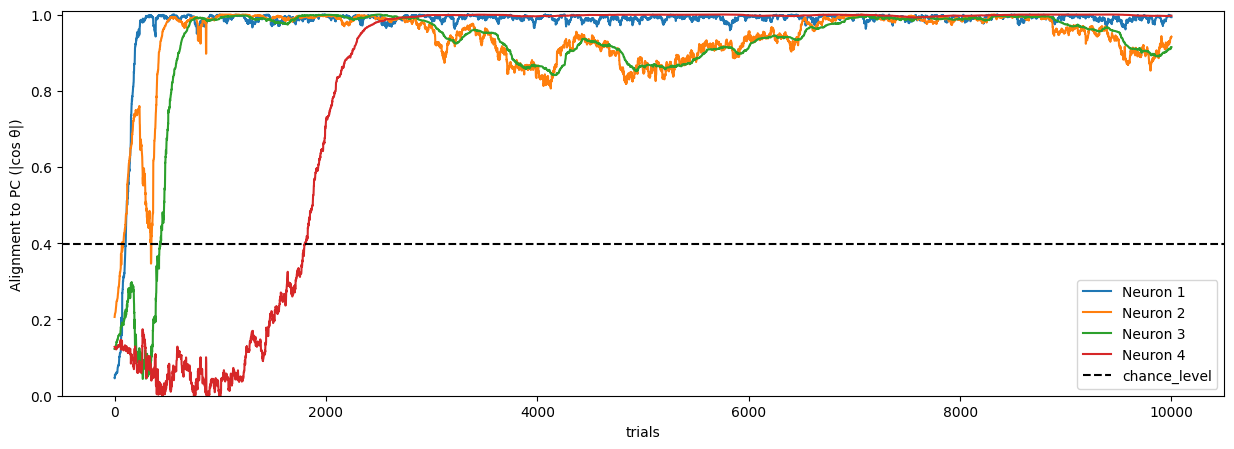

W after first phase: [[ 0.11579868  0.08723468  0.10548473  0.09400813 -0.11742211 -0.16970138
  -0.16648233  0.15500905 -0.0559716  -0.05884694 -0.17541429 -0.01544179
  -0.04169162 -0.22015504  0.06857029  0.02881936 -0.01868637  0.03719253
   0.02710921 -0.14760163  0.0612493  -0.31855303  0.039023    0.06624771
   0.14633707 -0.11220148 -0.1388383  -0.02603463 -0.14402131 -0.03404133
   0.06829287 -0.08292128  0.05352216 -0.02686685  0.17296366  0.04092911
  -0.24994785 -0.07205924  0.22318702 -0.18704854  0.06337975 -0.08313847
   0.03466437 -0.18219015 -0.00751916 -0.00906354 -0.10709472  0.14847793
   0.07186101 -0.01410334  0.01313994  0.12119886 -0.02233465 -0.12807565
   0.07569449 -0.05692073  0.11455441 -0.06197095 -0.05360402  0.00215333
  -0.42966037  0.00536848 -0.02872465 -0.20979874]
 [ 0.04045316  0.15567761 -0.05384304  0.00047498  0.10960133 -0.29373717
  -0.28043077  0.01141832 -0.08618648 -0.0492209   0.12935169 -0.05200995
  -0.22089214 -0.15318028  0.05778386  0

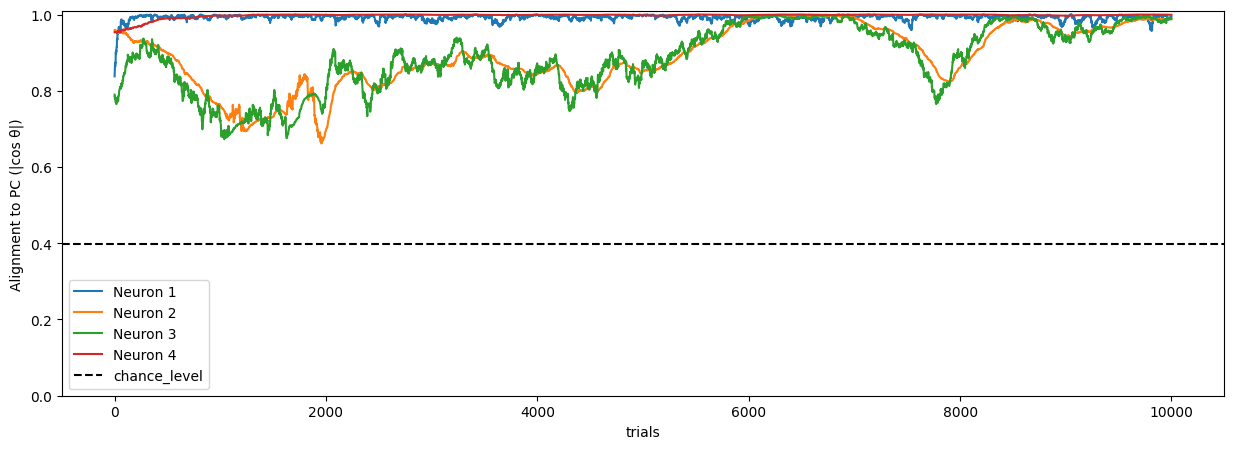

after second phase: model.W = [[ 1.43261443e-01  4.35643897e-02  1.92371929e-02  3.76434944e-02
  -2.16676702e-01 -1.86587237e-02  3.55508806e-02  1.63049063e-01
  -7.43931813e-02  3.42325491e-03 -1.76556198e-01 -4.25771188e-02
   7.28146997e-02 -7.04530290e-02  3.97832233e-02 -7.68793411e-02
  -3.77543301e-02  4.80477526e-02 -1.91878916e-02 -5.83971551e-02
   1.32511795e-01 -2.73181710e-01 -2.57299082e-02 -6.94179807e-02
   1.75568118e-01 -1.08740975e-01 -2.13860840e-01  4.82151904e-02
  -3.09527728e-02 -6.02293259e-02  1.50674833e-02 -5.27348589e-02
   5.39954899e-02 -7.56420762e-02  2.67115913e-01  6.01489879e-02
  -1.96838290e-01 -8.98610916e-02  2.73276381e-01 -2.19804732e-01
   1.28138115e-02 -2.07851751e-01 -1.66107776e-02 -3.66864662e-02
  -6.16934073e-02 -3.51874775e-02 -1.22252705e-01  1.72979487e-01
   6.14709051e-02 -1.67919239e-02  4.04192802e-02  1.23510787e-01
  -3.05666607e-02  1.93304082e-02 -1.31681397e-02 -1.17340536e-01
   1.17136099e-02  3.22159189e-02 -1.90217196e

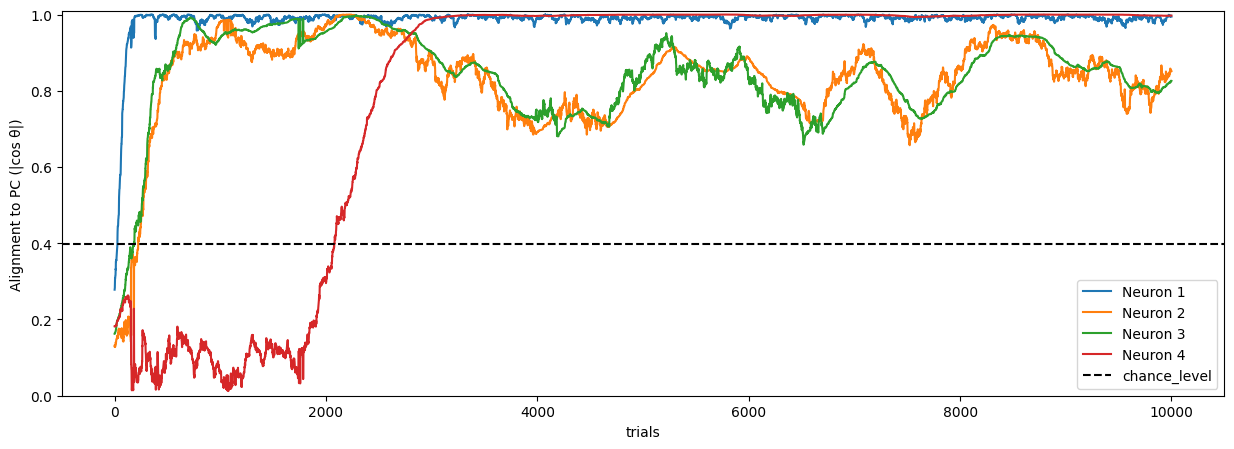

W after first phase: [[-0.11258859 -0.08482775 -0.09814229 -0.08832245  0.11455799  0.16259203
   0.15736194 -0.15002301  0.05670505  0.05442678  0.16564954  0.01465949
   0.03912081  0.20816698 -0.06537053 -0.02423934  0.01683325 -0.0342541
  -0.02710778  0.13972779 -0.05816916  0.30147602 -0.03451841 -0.06042468
  -0.14369707  0.10701161  0.13480718  0.0264407   0.13439383  0.03139686
  -0.06481676  0.07743647 -0.05256761  0.02757359 -0.16741565 -0.04036669
   0.23881131  0.06826088 -0.2140946   0.18149481 -0.05932912  0.08188742
  -0.03326442  0.17104887  0.00757141  0.00582486  0.10156232 -0.14224554
  -0.07139735  0.01295534 -0.01103001 -0.11560493  0.02317363  0.11960977
  -0.07165077  0.05433388 -0.10531742  0.05678634  0.05242808 -0.00324019
   0.40834637 -0.00367554  0.02739023  0.20073814]
 [ 0.07014817  0.16615516 -0.0954229  -0.02165806  0.06441305 -0.27744524
  -0.23345243  0.03516718 -0.12112947 -0.02453964  0.14059758 -0.06383211
  -0.19703794 -0.1140497   0.05518891  0.

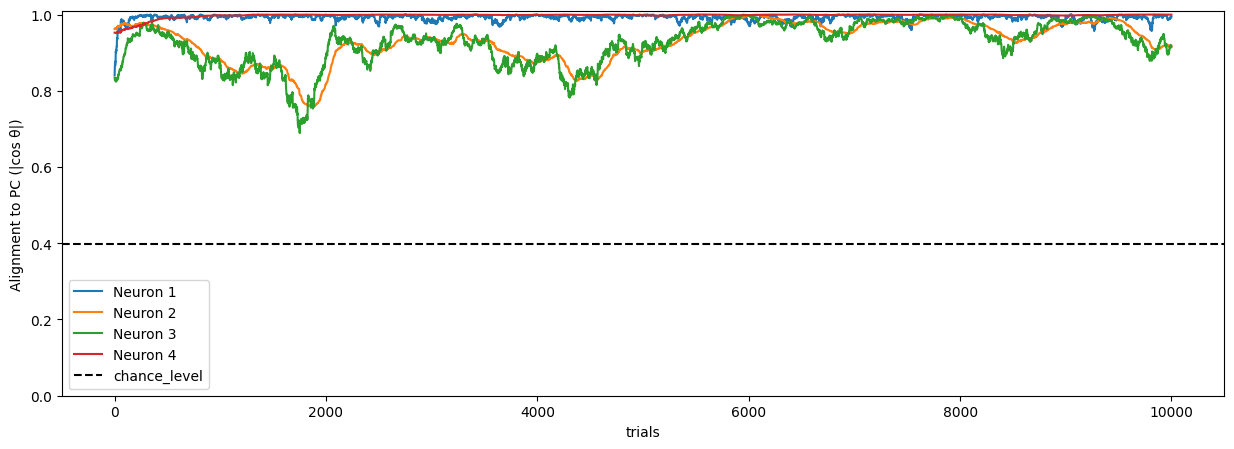

after second phase: model.W = [[-0.14326144 -0.04356439 -0.01923719 -0.03764349  0.2166767   0.01865872
  -0.03555088 -0.16304906  0.07439318 -0.00342325  0.1765562   0.04257712
  -0.0728147   0.07045303 -0.03978322  0.07687934  0.03775433 -0.04804775
   0.01918789  0.05839716 -0.1325118   0.27318171  0.02572991  0.06941798
  -0.17556812  0.10874098  0.21386084 -0.04821519  0.03095277  0.06022933
  -0.01506748  0.05273486 -0.05399549  0.07564208 -0.26711591 -0.06014899
   0.19683829  0.08986109 -0.27327638  0.21980473 -0.01281381  0.20785175
   0.01661078  0.03668647  0.06169341  0.03518748  0.12225271 -0.17297949
  -0.06147091  0.01679192 -0.04041928 -0.12351079  0.03056666 -0.01933041
   0.01316814  0.11734054 -0.01171361 -0.03221592  0.01902172  0.03461679
   0.41044072  0.00281239  0.00476048  0.06523324]
 [ 0.14729928  0.19684975 -0.13438837 -0.04391464 -0.06128718 -0.26605802
  -0.15874068  0.13109794 -0.21595393  0.02918277  0.12964787 -0.04569095
  -0.13341485 -0.06534315  0.05

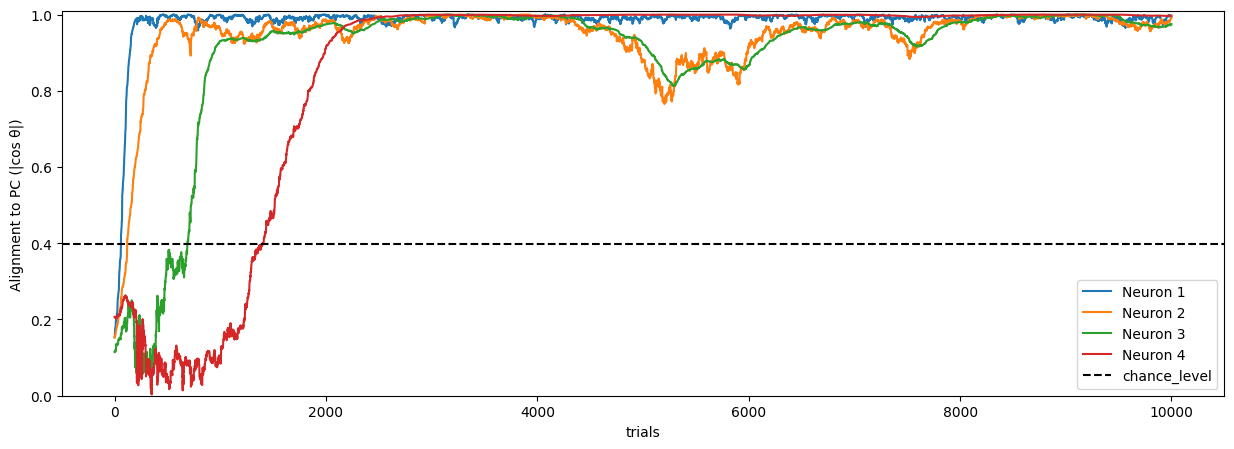

W after first phase: [[ 0.11258859  0.08482775  0.09814229  0.08832245 -0.11455799 -0.16259203
  -0.15736194  0.15002301 -0.05670505 -0.05442678 -0.16564954 -0.01465949
  -0.03912081 -0.20816698  0.06537053  0.02423934 -0.01683325  0.0342541
   0.02710778 -0.13972779  0.05816916 -0.30147602  0.03451841  0.06042468
   0.14369707 -0.10701161 -0.13480718 -0.0264407  -0.13439383 -0.03139686
   0.06481676 -0.07743647  0.05256761 -0.02757359  0.16741565  0.04036669
  -0.23881131 -0.06826088  0.2140946  -0.18149481  0.05932912 -0.08188742
   0.03326442 -0.17104887 -0.00757141 -0.00582486 -0.10156232  0.14224554
   0.07139735 -0.01295534  0.01103001  0.11560493 -0.02317363 -0.11960977
   0.07165077 -0.05433388  0.10531742 -0.05678634 -0.05242808  0.00324019
  -0.40834637  0.00367554 -0.02739023 -0.20073814]
 [-0.00389237 -0.12373491  0.00179552 -0.0235617  -0.14106066  0.27095433
   0.29104904  0.01322899  0.0398836   0.06690669 -0.10098858  0.0290745
   0.21454315  0.17227909 -0.05193845 -0.1

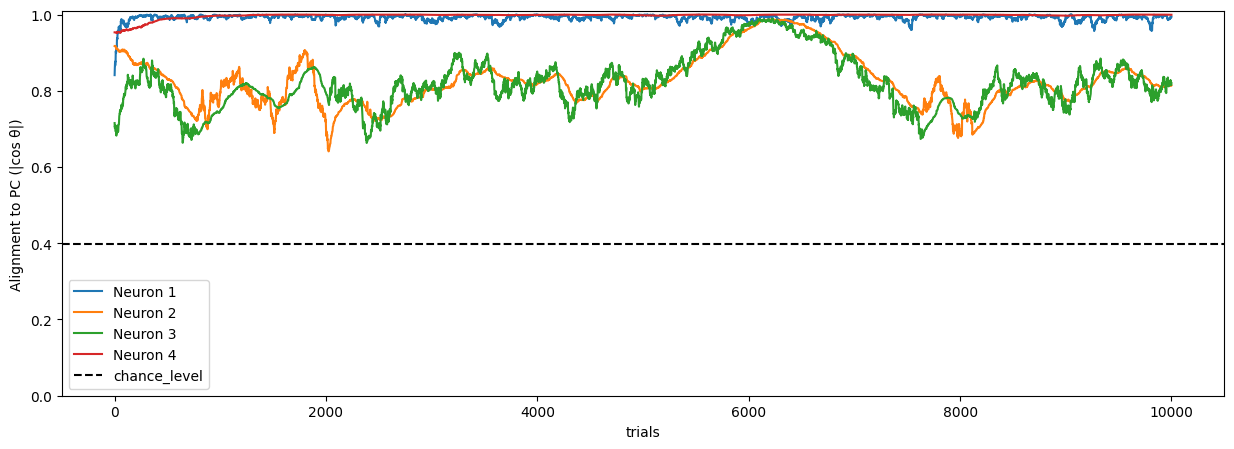

after second phase: model.W = [[ 0.14326144  0.04356439  0.01923719  0.03764349 -0.2166767  -0.01865872
   0.03555088  0.16304906 -0.07439318  0.00342325 -0.1765562  -0.04257712
   0.0728147  -0.07045303  0.03978322 -0.07687934 -0.03775433  0.04804775
  -0.01918789 -0.05839716  0.1325118  -0.27318171 -0.02572991 -0.06941798
   0.17556812 -0.10874098 -0.21386084  0.04821519 -0.03095277 -0.06022933
   0.01506748 -0.05273486  0.05399549 -0.07564208  0.26711591  0.06014899
  -0.19683829 -0.08986109  0.27327638 -0.21980473  0.01281381 -0.20785175
  -0.01661078 -0.03668647 -0.06169341 -0.03518748 -0.12225271  0.17297949
   0.06147091 -0.01679192  0.04041928  0.12351079 -0.03056666  0.01933041
  -0.01316814 -0.11734054  0.01171361  0.03221592 -0.01902172 -0.03461679
  -0.41044072 -0.00281239 -0.00476048 -0.06523324]
 [-0.03230324 -0.13690139 -0.09580086 -0.07542429 -0.0818669   0.31253774
   0.33981213 -0.07164919  0.0698024   0.07137486 -0.01968045 -0.04277722
   0.18991654  0.24676534 -0.06

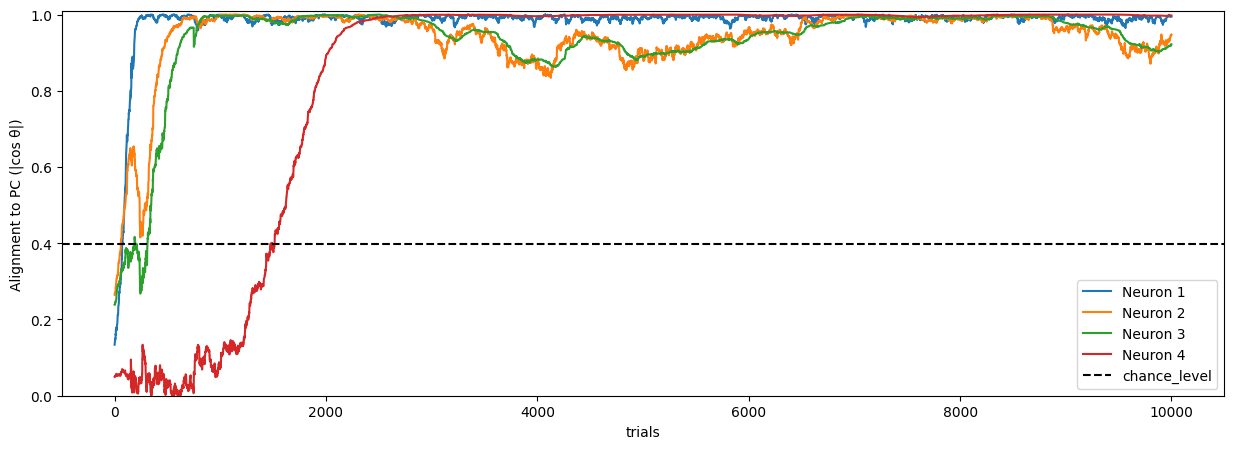

W after first phase: [[ 1.12588588e-01  8.48277544e-02  9.81422944e-02  8.83224496e-02
  -1.14557995e-01 -1.62592025e-01 -1.57361943e-01  1.50023013e-01
  -5.67050455e-02 -5.44267840e-02 -1.65649539e-01 -1.46594855e-02
  -3.91208058e-02 -2.08166981e-01  6.53705321e-02  2.42393422e-02
  -1.68332541e-02  3.42540970e-02  2.71077791e-02 -1.39727789e-01
   5.81691583e-02 -3.01476020e-01  3.45184141e-02  6.04246781e-02
   1.43697066e-01 -1.07011612e-01 -1.34807176e-01 -2.64407029e-02
  -1.34393835e-01 -3.13968580e-02  6.48167615e-02 -7.74364709e-02
   5.25676108e-02 -2.75735929e-02  1.67415654e-01  4.03666948e-02
  -2.38811312e-01 -6.82608832e-02  2.14094599e-01 -1.81494809e-01
   5.93291219e-02 -8.18874246e-02  3.32644161e-02 -1.71048875e-01
  -7.57140863e-03 -5.82486167e-03 -1.01562318e-01  1.42245545e-01
   7.13973464e-02 -1.29553364e-02  1.10300122e-02  1.15604933e-01
  -2.31736316e-02 -1.19609765e-01  7.16507683e-02 -5.43338753e-02
   1.05317420e-01 -5.67863415e-02 -5.24280802e-02  3.24

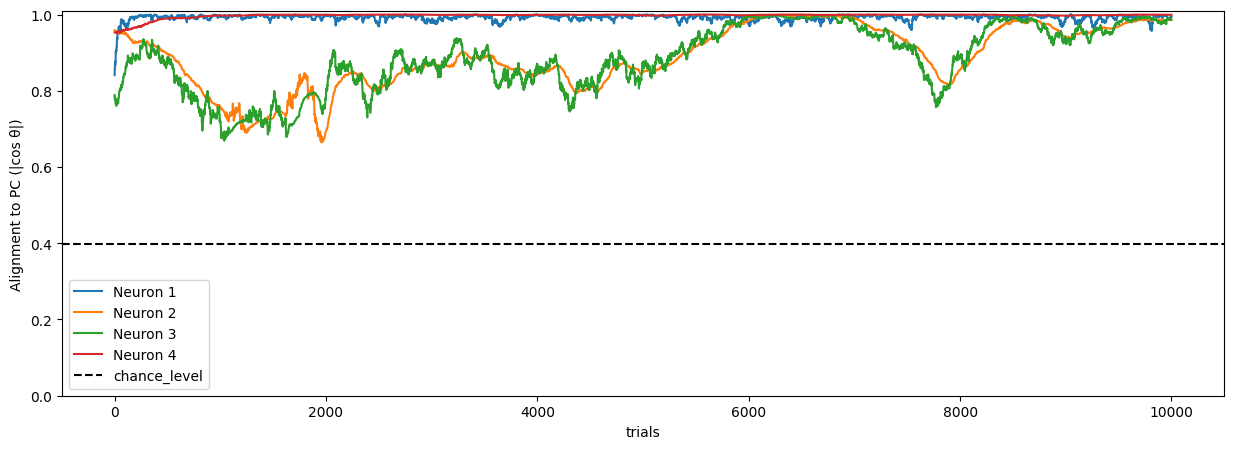

after second phase: model.W = [[ 0.14326144  0.04356439  0.01923719  0.03764349 -0.2166767  -0.01865872
   0.03555088  0.16304906 -0.07439318  0.00342325 -0.1765562  -0.04257712
   0.0728147  -0.07045303  0.03978322 -0.07687934 -0.03775433  0.04804775
  -0.01918789 -0.05839716  0.1325118  -0.27318171 -0.02572991 -0.06941798
   0.17556812 -0.10874098 -0.21386084  0.04821519 -0.03095277 -0.06022933
   0.01506748 -0.05273486  0.05399549 -0.07564208  0.26711591  0.06014899
  -0.19683829 -0.08986109  0.27327638 -0.21980473  0.01281381 -0.20785175
  -0.01661078 -0.03668647 -0.06169341 -0.03518748 -0.12225271  0.17297949
   0.06147091 -0.01679192  0.04041928  0.12351079 -0.03056666  0.01933041
  -0.01316814 -0.11734054  0.01171361  0.03221592 -0.01902172 -0.03461679
  -0.41044072 -0.00281239 -0.00476048 -0.06523324]
 [ 0.09838779  0.18844253 -0.01367982  0.0223477   0.01700698 -0.33217848
  -0.29138157  0.11358777 -0.15783854 -0.027803    0.08126743  0.00147416
  -0.18677885 -0.1849105   0.06

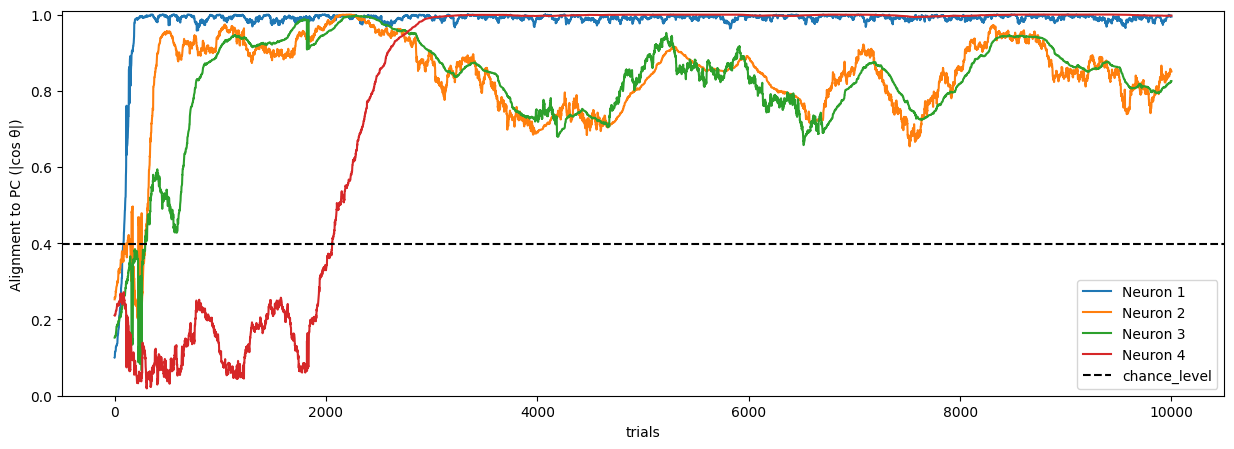

W after first phase: [[ 0.11258859  0.08482775  0.09814229  0.08832245 -0.11455799 -0.16259203
  -0.15736194  0.15002301 -0.05670505 -0.05442678 -0.16564954 -0.01465949
  -0.03912081 -0.20816698  0.06537053  0.02423934 -0.01683325  0.0342541
   0.02710778 -0.13972779  0.05816916 -0.30147602  0.03451841  0.06042468
   0.14369707 -0.10701161 -0.13480718 -0.0264407  -0.13439383 -0.03139686
   0.06481676 -0.07743647  0.05256761 -0.02757359  0.16741565  0.04036669
  -0.23881131 -0.06826088  0.2140946  -0.18149481  0.05932912 -0.08188742
   0.03326442 -0.17104887 -0.00757141 -0.00582486 -0.10156232  0.14224554
   0.07139735 -0.01295534  0.01103001  0.11560493 -0.02317363 -0.11960977
   0.07165077 -0.05433388  0.10531742 -0.05678634 -0.05242808  0.00324019
  -0.40834637  0.00367554 -0.02739023 -0.20073814]
 [ 0.07032683  0.16623673 -0.09567641 -0.02178721  0.06416682 -0.27738938
  -0.23321716  0.03530219 -0.12133932 -0.02440636  0.14067792 -0.06391817
  -0.19693217 -0.11384479  0.05518354  0.

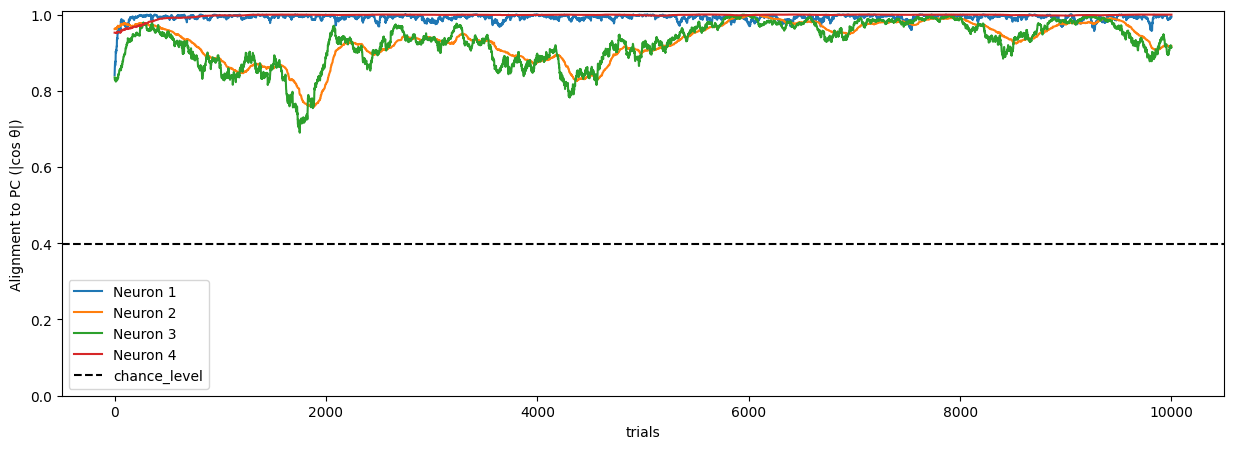

after second phase: model.W = [[ 0.14326144  0.04356439  0.01923719  0.03764349 -0.2166767  -0.01865872
   0.03555088  0.16304906 -0.07439318  0.00342325 -0.1765562  -0.04257712
   0.0728147  -0.07045303  0.03978322 -0.07687934 -0.03775433  0.04804775
  -0.01918789 -0.05839716  0.1325118  -0.27318171 -0.02572991 -0.06941798
   0.17556812 -0.10874098 -0.21386084  0.04821519 -0.03095277 -0.06022933
   0.01506748 -0.05273486  0.05399549 -0.07564208  0.26711591  0.06014899
  -0.19683829 -0.08986109  0.27327638 -0.21980473  0.01281381 -0.20785175
  -0.01661078 -0.03668647 -0.06169341 -0.03518748 -0.12225271  0.17297949
   0.06147091 -0.01679192  0.04041928  0.12351079 -0.03056666  0.01933041
  -0.01316814 -0.11734054  0.01171361  0.03221592 -0.01902172 -0.03461679
  -0.41044072 -0.00281239 -0.00476048 -0.06523324]
 [ 0.14743712  0.19675192 -0.13489092 -0.04421163 -0.0616314  -0.26554214
  -0.15797147  0.13109168 -0.21608861  0.02944418  0.12979552 -0.04589231
  -0.13305617 -0.06470488  0.05

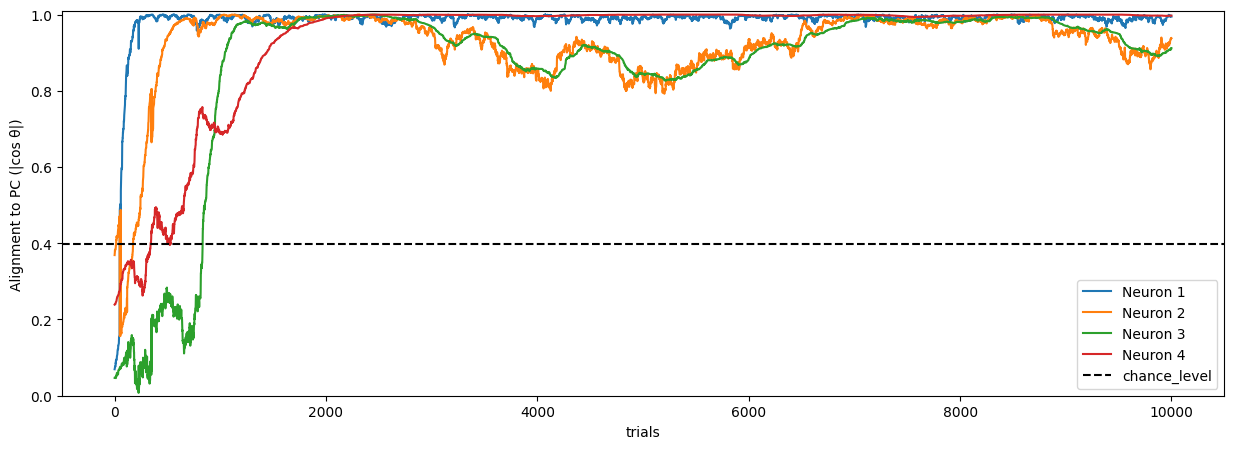

W after first phase: [[-0.11258859 -0.08482775 -0.09814229 -0.08832245  0.11455799  0.16259203
   0.15736194 -0.15002301  0.05670505  0.05442678  0.16564954  0.01465949
   0.03912081  0.20816698 -0.06537053 -0.02423934  0.01683325 -0.0342541
  -0.02710778  0.13972779 -0.05816916  0.30147602 -0.03451841 -0.06042468
  -0.14369707  0.10701161  0.13480718  0.0264407   0.13439383  0.03139686
  -0.06481676  0.07743647 -0.05256761  0.02757359 -0.16741565 -0.04036669
   0.23881131  0.06826088 -0.2140946   0.18149481 -0.05932912  0.08188742
  -0.03326442  0.17104887  0.00757141  0.00582486  0.10156232 -0.14224554
  -0.07139735  0.01295534 -0.01103001 -0.11560493  0.02317363  0.11960977
  -0.07165077  0.05433388 -0.10531742  0.05678634  0.05242808 -0.00324019
   0.40834637 -0.00367554  0.02739023  0.20073814]
 [ 0.04014201  0.14976702 -0.05293075 -0.00055762  0.10252667 -0.28081702
  -0.26641592  0.01286133 -0.0851272  -0.04536626  0.12493286 -0.04875374
  -0.21000484 -0.14454342  0.05493327  0.

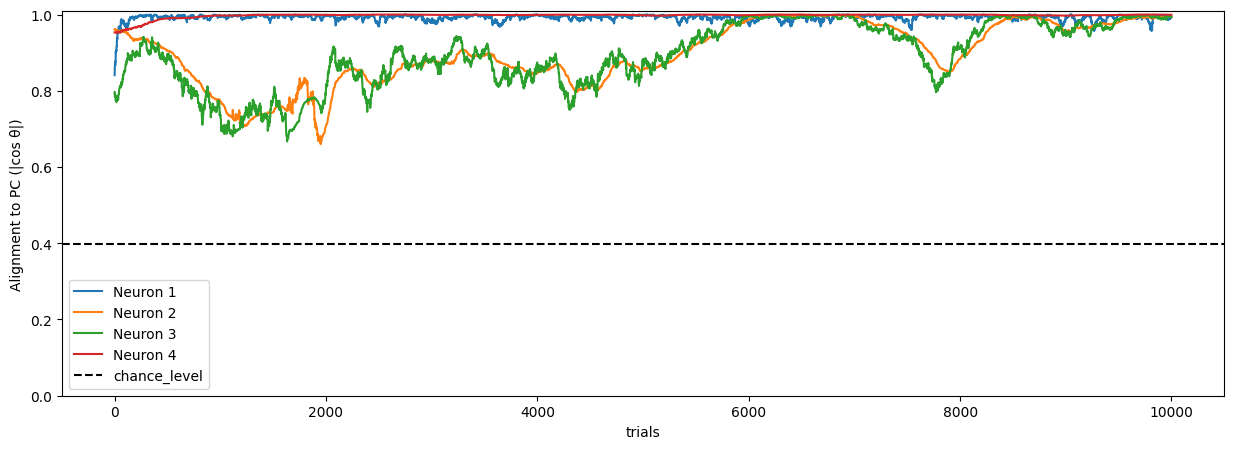

after second phase: model.W = [[-0.14326144 -0.04356439 -0.01923719 -0.03764349  0.2166767   0.01865872
  -0.03555088 -0.16304906  0.07439318 -0.00342325  0.1765562   0.04257712
  -0.0728147   0.07045303 -0.03978322  0.07687934  0.03775433 -0.04804775
   0.01918789  0.05839716 -0.1325118   0.27318171  0.02572991  0.06941798
  -0.17556812  0.10874098  0.21386084 -0.04821519  0.03095277  0.06022933
  -0.01506748  0.05273486 -0.05399549  0.07564208 -0.26711591 -0.06014899
   0.19683829  0.08986109 -0.27327638  0.21980473 -0.01281381  0.20785175
   0.01661078  0.03668647  0.06169341  0.03518748  0.12225271 -0.17297949
  -0.06147091  0.01679192 -0.04041928 -0.12351079  0.03056666 -0.01933041
   0.01316814  0.11734054 -0.01171361 -0.03221592  0.01902172  0.03461679
   0.41044072  0.00281239  0.00476048  0.06523324]
 [ 0.10689318  0.19287427 -0.0307059   0.01351903  0.00641469 -0.32873424
  -0.27798042  0.11798694 -0.16865121 -0.02036089  0.08940262 -0.005064
  -0.18259321 -0.17148432  0.0650

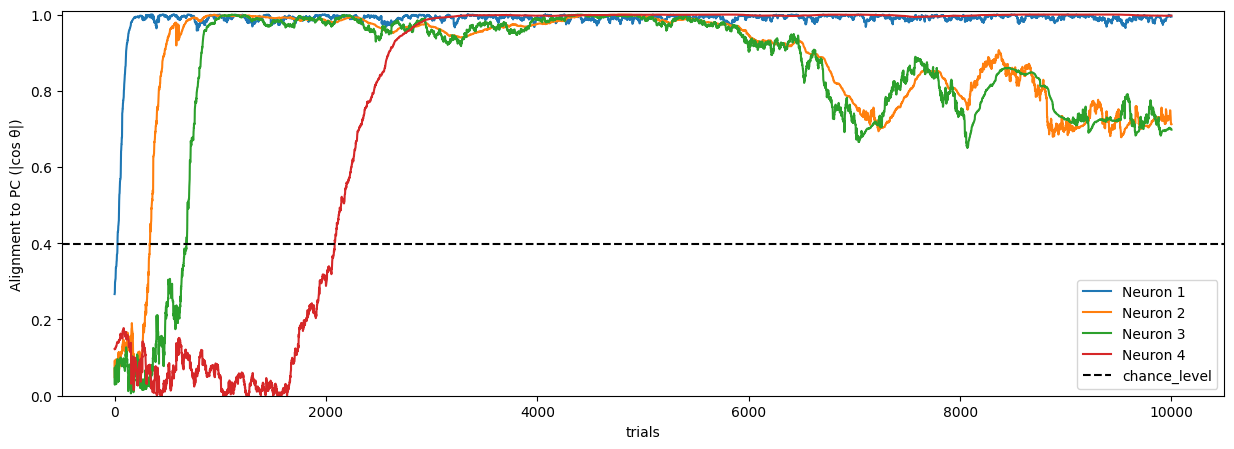

W after first phase: [[ 0.11258859  0.08482775  0.09814229  0.08832245 -0.11455799 -0.16259203
  -0.15736194  0.15002301 -0.05670505 -0.05442678 -0.16564954 -0.01465949
  -0.03912081 -0.20816698  0.06537053  0.02423934 -0.01683325  0.0342541
   0.02710778 -0.13972779  0.05816916 -0.30147602  0.03451841  0.06042468
   0.14369707 -0.10701161 -0.13480718 -0.0264407  -0.13439383 -0.03139686
   0.06481676 -0.07743647  0.05256761 -0.02757359  0.16741565  0.04036669
  -0.23881131 -0.06826088  0.2140946  -0.18149481  0.05932912 -0.08188742
   0.03326442 -0.17104887 -0.00757141 -0.00582486 -0.10156232  0.14224554
   0.07139735 -0.01295534  0.01103001  0.11560493 -0.02317363 -0.11960977
   0.07165077 -0.05433388  0.10531742 -0.05678634 -0.05242808  0.00324019
  -0.40834637  0.00367554 -0.02739023 -0.20073814]
 [ 0.12351505  0.02518469 -0.17606573 -0.09577551 -0.20745509  0.10800852
   0.23791251  0.09722075 -0.13552468  0.1095113   0.02961791 -0.05316606
   0.12821459  0.18618974 -0.01678881 -0.

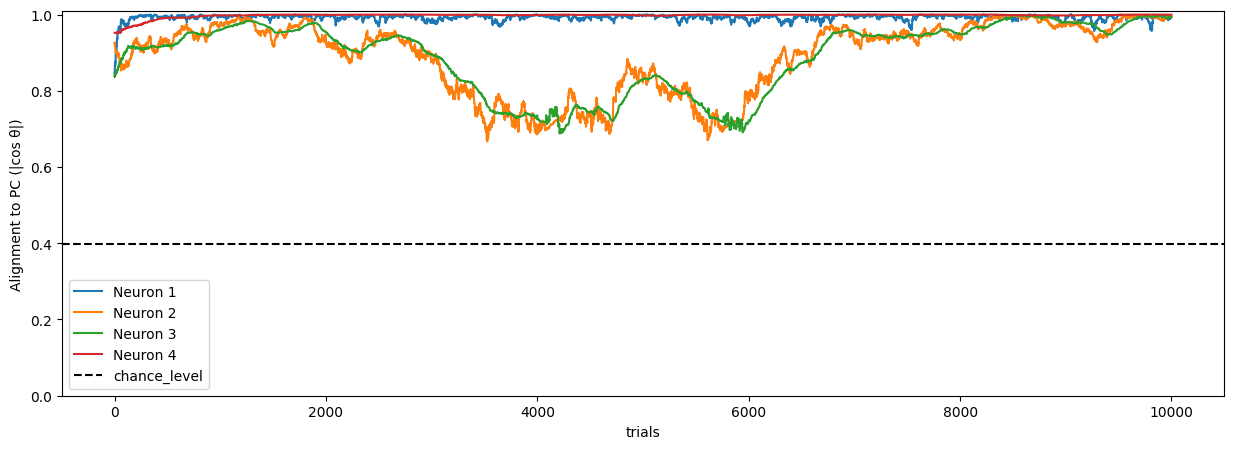

after second phase: model.W = [[ 1.43261443e-01  4.35643897e-02  1.92371929e-02  3.76434944e-02
  -2.16676702e-01 -1.86587237e-02  3.55508806e-02  1.63049063e-01
  -7.43931813e-02  3.42325491e-03 -1.76556198e-01 -4.25771188e-02
   7.28146997e-02 -7.04530290e-02  3.97832233e-02 -7.68793411e-02
  -3.77543301e-02  4.80477526e-02 -1.91878916e-02 -5.83971551e-02
   1.32511795e-01 -2.73181710e-01 -2.57299082e-02 -6.94179807e-02
   1.75568118e-01 -1.08740975e-01 -2.13860840e-01  4.82151904e-02
  -3.09527728e-02 -6.02293259e-02  1.50674833e-02 -5.27348589e-02
   5.39954899e-02 -7.56420762e-02  2.67115913e-01  6.01489879e-02
  -1.96838290e-01 -8.98610916e-02  2.73276381e-01 -2.19804732e-01
   1.28138115e-02 -2.07851751e-01 -1.66107776e-02 -3.66864662e-02
  -6.16934073e-02 -3.51874775e-02 -1.22252705e-01  1.72979487e-01
   6.14709051e-02 -1.67919239e-02  4.04192802e-02  1.23510787e-01
  -3.05666607e-02  1.93304082e-02 -1.31681397e-02 -1.17340536e-01
   1.17136099e-02  3.22159189e-02 -1.90217196e

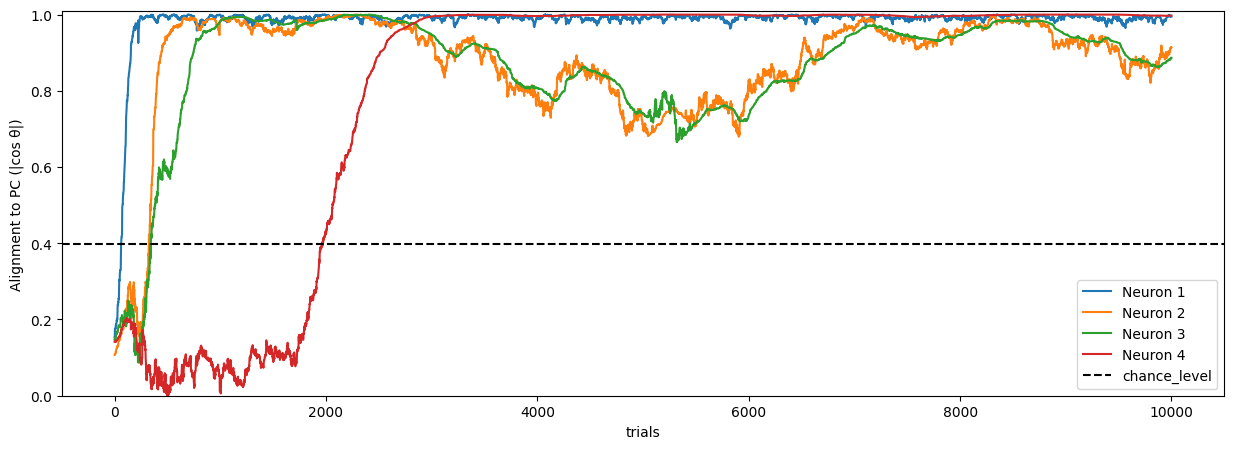

W after first phase: [[-0.11258859 -0.08482775 -0.09814229 -0.08832245  0.11455799  0.16259203
   0.15736194 -0.15002301  0.05670505  0.05442678  0.16564954  0.01465949
   0.03912081  0.20816698 -0.06537053 -0.02423934  0.01683325 -0.0342541
  -0.02710778  0.13972779 -0.05816916  0.30147602 -0.03451841 -0.06042468
  -0.14369707  0.10701161  0.13480718  0.0264407   0.13439383  0.03139686
  -0.06481676  0.07743647 -0.05256761  0.02757359 -0.16741565 -0.04036669
   0.23881131  0.06826088 -0.2140946   0.18149481 -0.05932912  0.08188742
  -0.03326442  0.17104887  0.00757141  0.00582486  0.10156232 -0.14224554
  -0.07139735  0.01295534 -0.01103001 -0.11560493  0.02317363  0.11960977
  -0.07165077  0.05433388 -0.10531742  0.05678634  0.05242808 -0.00324019
   0.40834637 -0.00367554  0.02739023  0.20073814]
 [ 0.05020665  0.15582868 -0.06716579 -0.00751126  0.09042274 -0.28094822
  -0.25673465  0.02026576 -0.09736225 -0.03870789  0.13064268 -0.0539432
  -0.20666303 -0.13513893  0.05526204  0.0

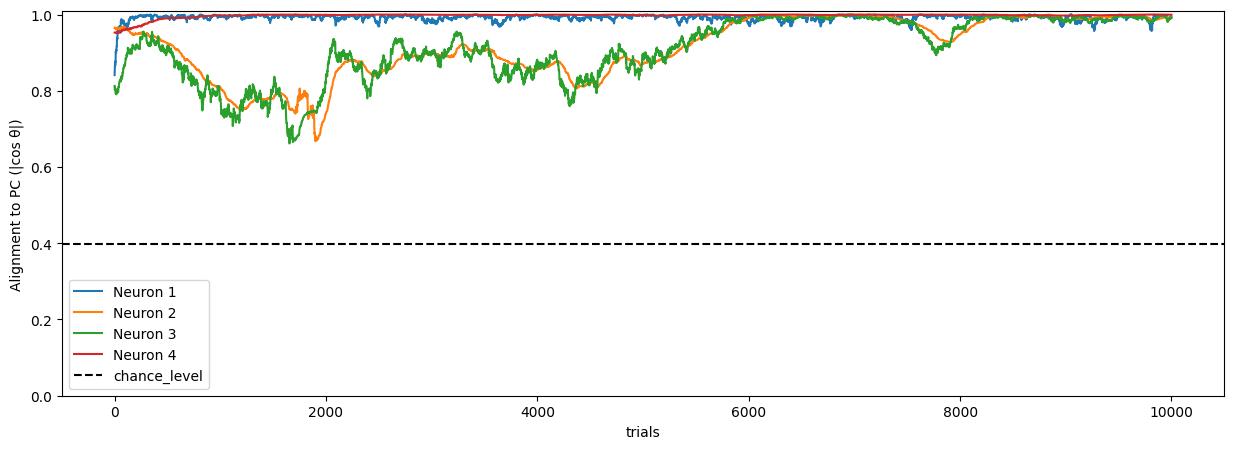

after second phase: model.W = [[-0.14326144 -0.04356439 -0.01923719 -0.03764349  0.2166767   0.01865872
  -0.03555088 -0.16304906  0.07439318 -0.00342325  0.1765562   0.04257712
  -0.0728147   0.07045303 -0.03978322  0.07687934  0.03775433 -0.04804775
   0.01918789  0.05839716 -0.1325118   0.27318171  0.02572991  0.06941798
  -0.17556812  0.10874098  0.21386084 -0.04821519  0.03095277  0.06022933
  -0.01506748  0.05273486 -0.05399549  0.07564208 -0.26711591 -0.06014899
   0.19683829  0.08986109 -0.27327638  0.21980473 -0.01281381  0.20785175
   0.01661078  0.03668647  0.06169341  0.03518748  0.12225271 -0.17297949
  -0.06147091  0.01679192 -0.04041928 -0.12351079  0.03056666 -0.01933041
   0.01316814  0.11734054 -0.01171361 -0.03221592  0.01902172  0.03461679
   0.41044072  0.00281239  0.00476048  0.06523324]
 [ 0.1241792   0.1992408  -0.06883124 -0.00681902 -0.01780192 -0.31457358
  -0.24215096  0.12572677 -0.19000133 -0.0030396   0.10618454 -0.01982466
  -0.16955476 -0.13764678  0.06

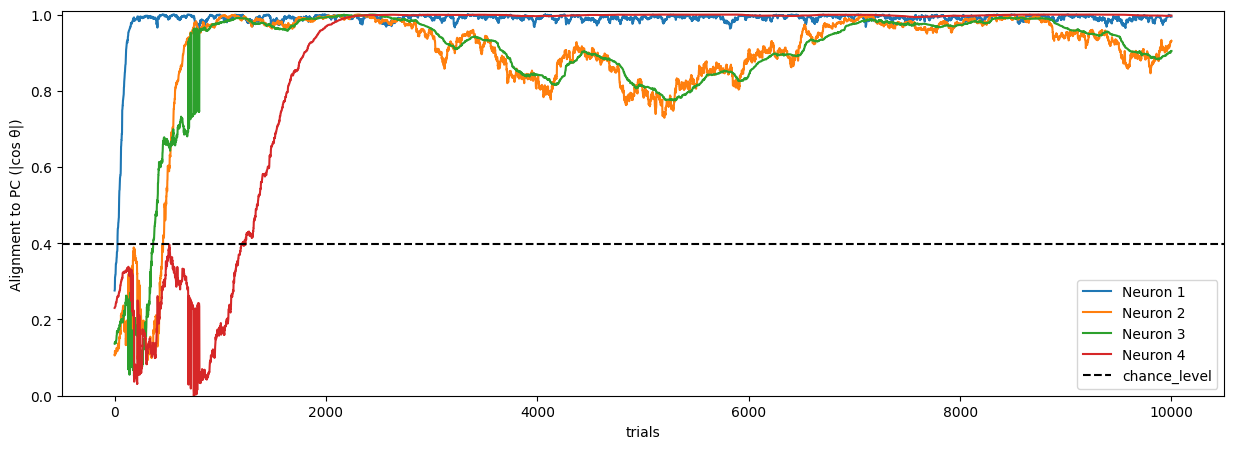

W after first phase: [[-0.11258859 -0.08482775 -0.09814229 -0.08832245  0.11455799  0.16259203
   0.15736194 -0.15002301  0.05670505  0.05442678  0.16564954  0.01465949
   0.03912081  0.20816698 -0.06537053 -0.02423934  0.01683325 -0.0342541
  -0.02710778  0.13972779 -0.05816916  0.30147602 -0.03451841 -0.06042468
  -0.14369707  0.10701161  0.13480718  0.0264407   0.13439383  0.03139686
  -0.06481676  0.07743647 -0.05256761  0.02757359 -0.16741565 -0.04036669
   0.23881131  0.06826088 -0.2140946   0.18149481 -0.05932912  0.08188742
  -0.03326442  0.17104887  0.00757141  0.00582486  0.10156232 -0.14224554
  -0.07139735  0.01295534 -0.01103001 -0.11560493  0.02317363  0.11960977
  -0.07165077  0.05433388 -0.10531742  0.05678634  0.05242808 -0.00324019
   0.40834637 -0.00367554  0.02739023  0.20073814]
 [ 0.04318355  0.15165536 -0.0572308  -0.00264659  0.09893692 -0.28098297
  -0.26362788  0.01509119 -0.08884051 -0.04338689  0.12670389 -0.05033526
  -0.20909578 -0.14178386  0.05505696  0.

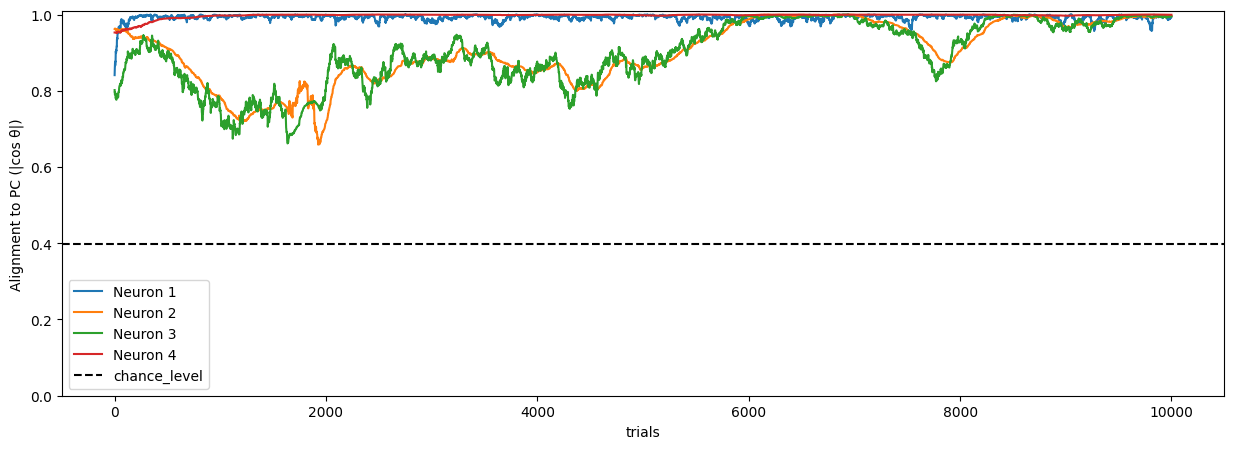

after second phase: model.W = [[-0.14326144 -0.04356439 -0.01923719 -0.03764349  0.2166767   0.01865872
  -0.03555088 -0.16304906  0.07439318 -0.00342325  0.1765562   0.04257712
  -0.0728147   0.07045303 -0.03978322  0.07687934  0.03775433 -0.04804775
   0.01918789  0.05839716 -0.1325118   0.27318171  0.02572991  0.06941798
  -0.17556812  0.10874098  0.21386084 -0.04821519  0.03095277  0.06022933
  -0.01506748  0.05273486 -0.05399549  0.07564208 -0.26711591 -0.06014899
   0.19683829  0.08986109 -0.27327638  0.21980473 -0.01281381  0.20785175
   0.01661078  0.03668647  0.06169341  0.03518748  0.12225271 -0.17297949
  -0.06147091  0.01679192 -0.04041928 -0.12351079  0.03056666 -0.01933041
   0.01316814  0.11734054 -0.01171361 -0.03221592  0.01902172  0.03461679
   0.41044072  0.00281239  0.00476048  0.06523324]
 [ 0.11245702  0.19535979 -0.04239509  0.00736863 -0.00093557 -0.3253597
  -0.26786809  0.12067676 -0.17562662 -0.01514852  0.09476325 -0.00957131
  -0.17914529 -0.16167551  0.064

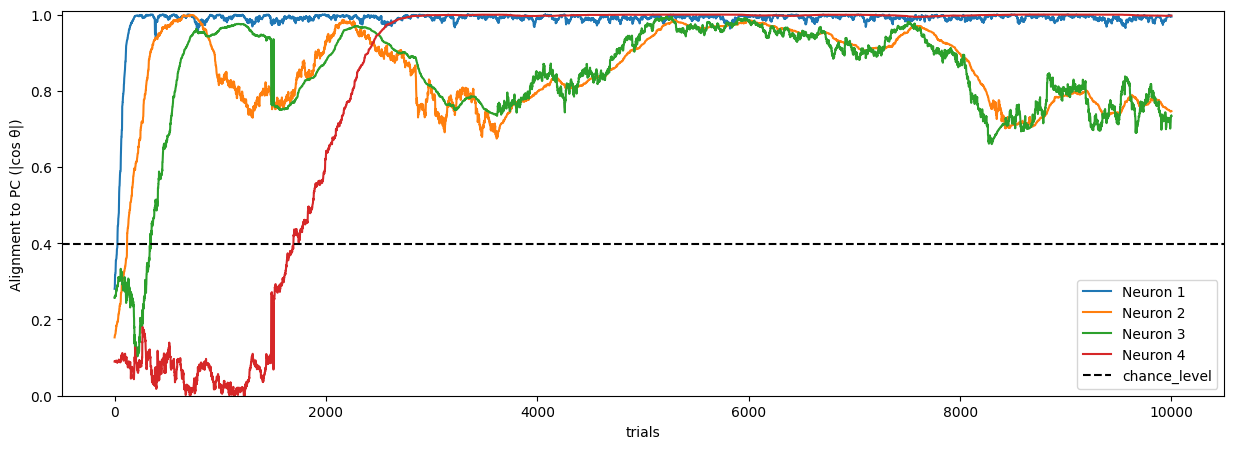

W after first phase: [[-0.11258859 -0.08482775 -0.09814229 -0.08832245  0.11455799  0.16259203
   0.15736194 -0.15002301  0.05670505  0.05442678  0.16564954  0.01465949
   0.03912081  0.20816698 -0.06537053 -0.02423934  0.01683325 -0.0342541
  -0.02710778  0.13972779 -0.05816916  0.30147602 -0.03451841 -0.06042468
  -0.14369707  0.10701161  0.13480718  0.0264407   0.13439383  0.03139686
  -0.06481676  0.07743647 -0.05256761  0.02757359 -0.16741565 -0.04036669
   0.23881131  0.06826088 -0.2140946   0.18149481 -0.05932912  0.08188742
  -0.03326442  0.17104887  0.00757141  0.00582486  0.10156232 -0.14224554
  -0.07139735  0.01295534 -0.01103001 -0.11560493  0.02317363  0.11960977
  -0.07165077  0.05433388 -0.10531742  0.05678634  0.05242808 -0.00324019
   0.40834637 -0.00367554  0.02739023  0.20073814]
 [-0.10792018 -0.17795001  0.14918043  0.05014391 -0.00580742  0.25346922
   0.17046919 -0.06444439  0.1639335  -0.0067722  -0.1531626   0.08078115
   0.16497349  0.06281396 -0.05172102  0.

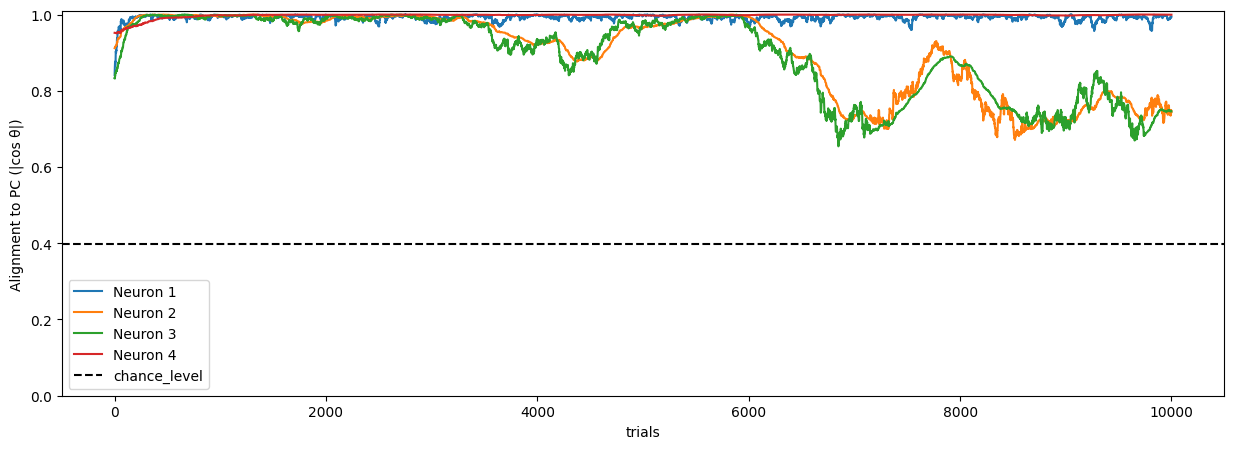

after second phase: model.W = [[-0.14326144 -0.04356439 -0.01923719 -0.03764349  0.2166767   0.01865872
  -0.03555088 -0.16304906  0.07439318 -0.00342325  0.1765562   0.04257712
  -0.0728147   0.07045303 -0.03978322  0.07687934  0.03775433 -0.04804775
   0.01918789  0.05839716 -0.1325118   0.27318171  0.02572991  0.06941798
  -0.17556812  0.10874098  0.21386084 -0.04821519  0.03095277  0.06022933
  -0.01506748  0.05273486 -0.05399549  0.07564208 -0.26711591 -0.06014899
   0.19683829  0.08986109 -0.27327638  0.21980473 -0.01281381  0.20785175
   0.01661078  0.03668647  0.06169341  0.03518748  0.12225271 -0.17297949
  -0.06147091  0.01679192 -0.04041928 -0.12351079  0.03056666 -0.01933041
   0.01316814  0.11734054 -0.01171361 -0.03221592  0.01902172  0.03461679
   0.41044072  0.00281239  0.00476048  0.06523324]
 [-0.15658738 -0.16221211  0.20575859  0.08937286  0.11297342  0.15524819
   0.01567164 -0.11780203  0.21826976 -0.07003292 -0.14219406  0.07513447
   0.06121126 -0.04718072 -0.03

<Figure size 640x480 with 0 Axes>

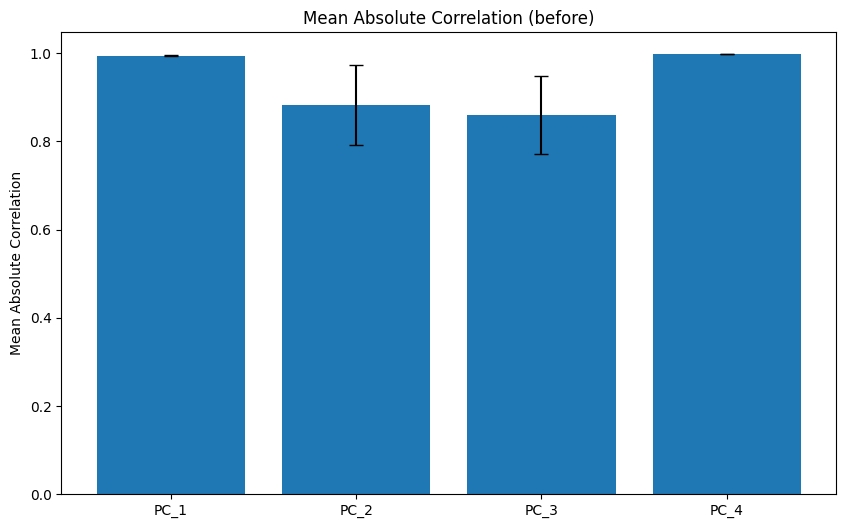

<Figure size 640x480 with 0 Axes>

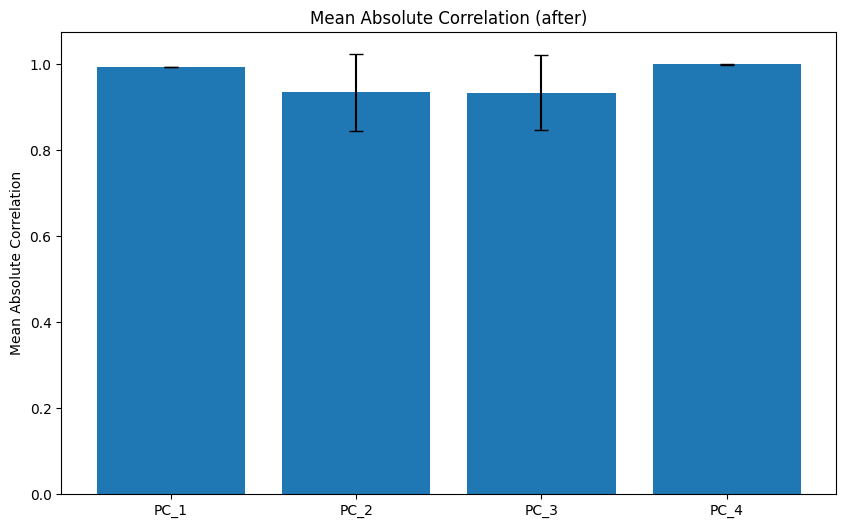

In [28]:
from hebbian.models import SangerNetwork
sanger_model = SangerNetwork(output_size=m, learning_rate=0.011, rng=None)

sanger_model_after = dict(learning_rate=0.01)

two_phase_training_testing(sanger_model, X_before, X_after, m, model_paras_after = sanger_model_after, runs = 10, graph = True)

### Leen's complete model

In [29]:
# runs = 10
model_paras = dict(
    input_dim=N, output_dim=m,
    eta_w=5e-4,          # base
    eta_v=5e-3,          # ~4x eta_w
    C=1.5,
    ema_alpha=0.03,
    symmetrize_V=True,
    seed=None,
    noise_level=0.001,
    # settling_steps=10
)

model_paras_after = dict(
    eta_w=5e-4,
    eta_v=5e-3,
    C=1.5,
#     eta_w=6e-5,          # base
#     eta_v=5e-4,          # ~4x eta_w
)

run  1
X_before
step    0 | order = [2 1 3 0] | best|corr|= [0.269 0.108 0.354 0.161]
step 1000 | order = [2 1 3 0] | best|corr|= [0.312 0.225 0.327 0.252]
step 2000 | order = [2 1 3 0] | best|corr|= [0.357 0.377 0.418 0.587]
step 3000 | order = [2 1 3 0] | best|corr|= [0.471 0.492 0.535 0.915]
step 4000 | order = [2 1 3 0] | best|corr|= [0.575 0.607 0.575 0.983]
step 5000 | order = [2 1 3 0] | best|corr|= [0.68  0.669 0.641 0.981]
step 6000 | order = [2 1 3 0] | best|corr|= [0.808 0.631 0.697 0.991]
step 7000 | order = [2 1 3 0] | best|corr|= [0.821 0.668 0.757 0.99 ]
step 8000 | order = [2 1 3 0] | best|corr|= [0.798 0.705 0.804 0.989]
step 9000 | order = [2 1 3 0] | best|corr|= [0.718 0.813 0.85  0.997]
step 10000 | order = [2 1 3 0] | best|corr|= [0.803 0.75  0.88  0.996]


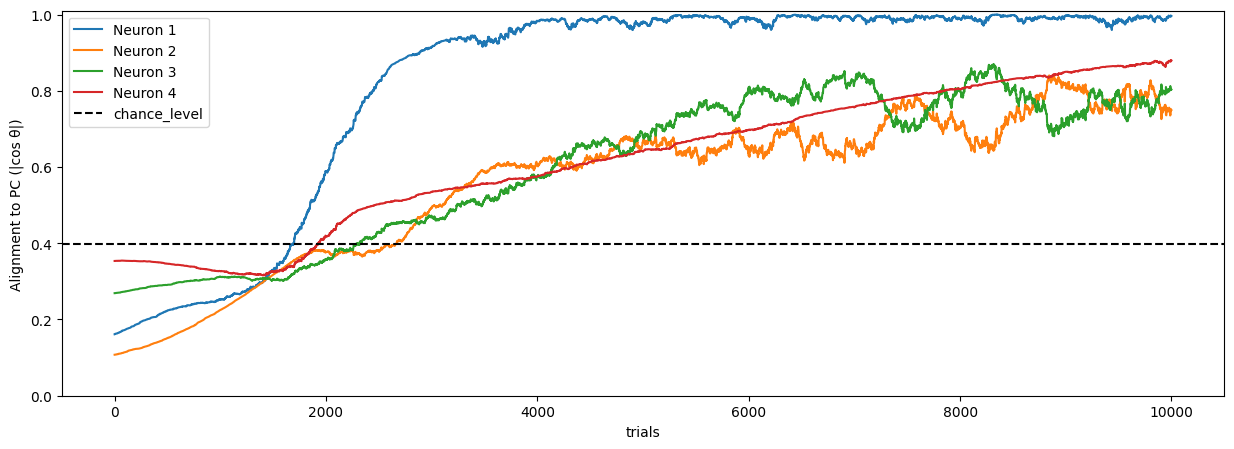

W after first phase: [[-1.40306926e-01 -3.89182561e-02  2.11895449e-01  8.51169576e-02
   2.07200854e-01 -7.15283883e-02 -2.32562575e-01 -1.04014037e-01
   1.65818827e-01 -1.23784932e-01 -5.63457407e-02  5.07093224e-02
  -1.04454069e-01 -1.79877975e-01  4.79490645e-03  2.06967691e-01
  -1.80806085e-02  4.08052762e-02 -1.60217288e-02 -6.35627473e-02
  -5.38855328e-02 -1.17668225e-01  1.72041535e-01  2.16253214e-01
  -2.04649953e-01 -7.19284462e-03  1.65617507e-01  2.05782597e-03
  -2.02945219e-01  1.24925492e-02  1.96674151e-02 -8.96454897e-02
  -6.56108576e-02  1.29392033e-01 -2.24558091e-01 -1.04652072e-01
  -2.15706801e-02  1.33887274e-02 -1.52054010e-01  1.74041210e-01
   8.62340584e-02  2.10196216e-01  3.82789916e-02 -1.96886911e-01
   1.93204059e-02 -9.06423862e-02 -5.04481626e-02 -6.74068844e-02
  -1.13129960e-01  9.14682070e-03  4.66588030e-02 -4.74332068e-02
   8.50844193e-02 -2.58768566e-01  7.89565084e-02  5.63014251e-02
   2.26663232e-01 -1.52873597e-01  1.15635840e-02 -1.44

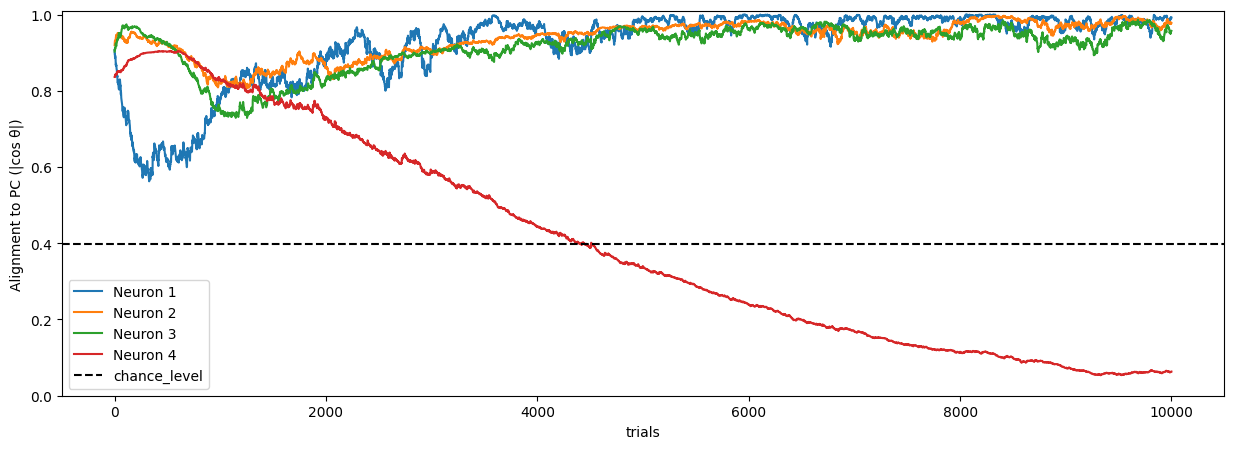

after second phase: model.W = [[-1.20455122e-01 -7.15311654e-02  2.01706592e-01  1.00493292e-01
   1.42463049e-01 -1.27185686e-02 -1.39479846e-01 -7.57029136e-02
   1.49154355e-01 -8.80698624e-02 -9.08164939e-02  7.81006350e-02
  -4.15394044e-02 -1.40625890e-01 -2.45136613e-04  1.53626610e-01
  -3.47682576e-02  6.99793142e-02 -2.66589212e-02 -2.37856251e-02
   9.30706605e-03 -1.56704302e-01  1.52035424e-01  1.41165289e-01
  -1.69993565e-01 -3.47706713e-02  8.53373735e-02  3.17228022e-02
  -1.60352953e-01  1.52320230e-03 -7.71732991e-03 -1.31409939e-01
  -5.42773806e-02  8.16525216e-02 -1.50973166e-01 -1.12599363e-01
  -7.17072416e-02 -1.04173421e-03 -1.02374092e-01  9.58004268e-02
   6.19529622e-02  1.25944073e-01  1.90271358e-02 -1.65882461e-01
  -4.27621029e-02 -9.66526062e-02 -1.32026465e-01 -2.21085537e-02
  -8.43456240e-02  2.60153316e-02  9.61950508e-02 -3.47133874e-02
   7.83394992e-02 -2.33447609e-01  5.51985799e-02  3.14419467e-02
   1.96477634e-01 -7.51178453e-02 -1.40290890e

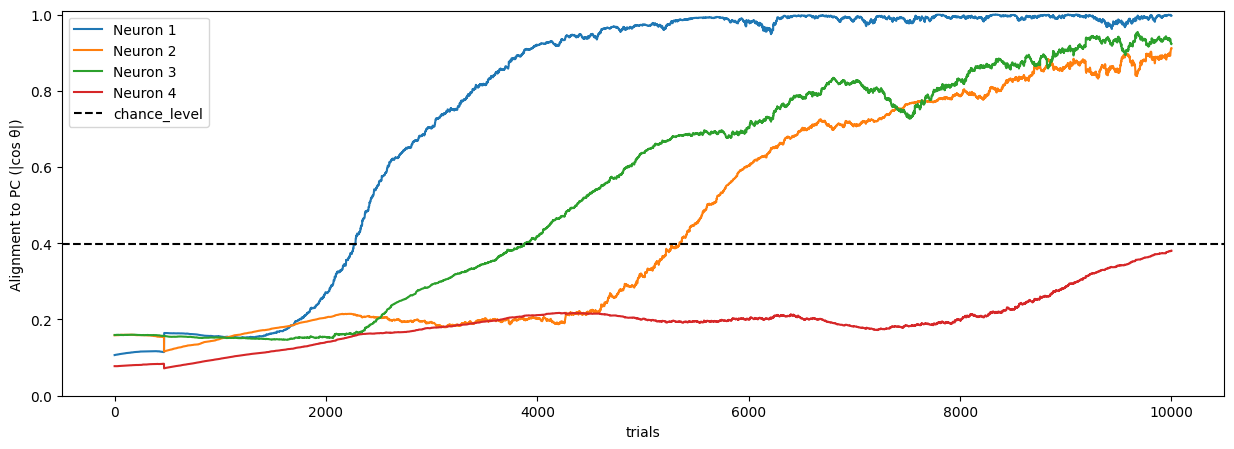

W after first phase: [[-1.31933323e-01 -9.22015342e-02 -8.33371815e-02 -8.21419436e-02
   1.42916823e-01  1.59243342e-01  1.39567925e-01 -1.67931076e-01
   7.40813752e-02  4.54479050e-02  1.70889099e-01  2.23040836e-02
   2.75163559e-02  1.98498749e-01 -6.70883423e-02 -3.60120624e-03
   1.69532926e-02 -3.26403030e-02 -2.73823719e-02  1.38114810e-01
  -6.85488169e-02  3.07374214e-01 -1.94684917e-02 -4.05630935e-02
  -1.70421233e-01  1.12322636e-01  1.59049119e-01  2.45518028e-02
   1.20801566e-01  3.49653773e-02 -6.41120294e-02  7.11656751e-02
  -6.08306208e-02  4.08772847e-02 -1.99308946e-01 -5.24267690e-02
   2.47214693e-01  7.42936105e-02 -2.40900268e-01  2.06261729e-01
  -5.40015876e-02  1.09573089e-01 -2.97580246e-02  1.56780536e-01
   1.19342958e-02  5.23920041e-04  1.02843048e-01 -1.56571812e-01
  -8.32228392e-02  1.48517597e-02 -7.84768131e-03 -1.25665724e-01
   3.19153788e-02  9.84811347e-02 -6.43806247e-02  6.58747697e-02
  -8.77602208e-02  4.48168262e-02  5.34792937e-02 -2.76

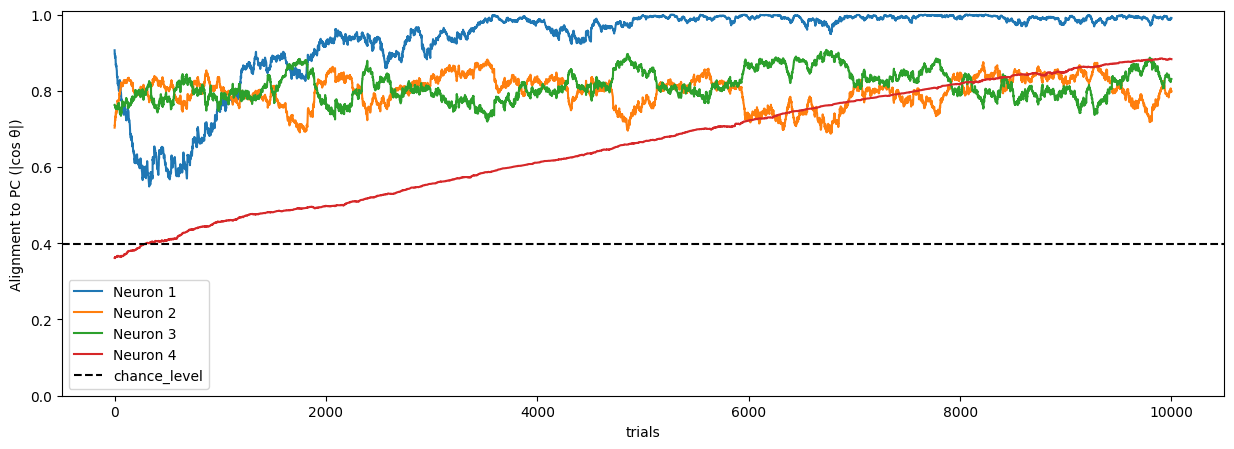

after second phase: model.W = [[-1.34950255e-01 -3.31234935e-02 -4.14060270e-02 -5.06412841e-02
   2.10787153e-01  1.33785388e-02 -2.74426515e-02 -1.57449718e-01
   5.42661115e-02  8.37806585e-03  1.99987806e-01  4.21995959e-02
  -7.39473541e-02  8.78864907e-02 -4.16548609e-02  5.88408612e-02
   4.72609163e-02 -6.09012355e-02  2.91718062e-02  6.66997153e-02
  -1.43417941e-01  3.08138493e-01  6.87586181e-03  5.47454154e-02
  -1.56255535e-01  1.16669028e-01  2.11007226e-01 -6.25962992e-02
   5.39423554e-02  6.98717182e-02 -1.61856308e-02  7.02840104e-02
  -4.64536778e-02  6.67435741e-02 -2.64259786e-01 -5.15465468e-02
   2.08413751e-01  9.79677983e-02 -2.78715820e-01  2.12186599e-01
  -2.14631358e-02  2.02612545e-01  1.87760970e-02  5.82898530e-02
   6.63074898e-02  5.73870347e-02  1.39099916e-01 -1.79096461e-01
  -4.55876524e-02  1.92029513e-02 -5.59324708e-02 -1.29007778e-01
   1.87961608e-02  1.30920613e-03  1.01852962e-02  1.23623161e-01
  -4.06974015e-02 -2.00646652e-02  1.31854704e

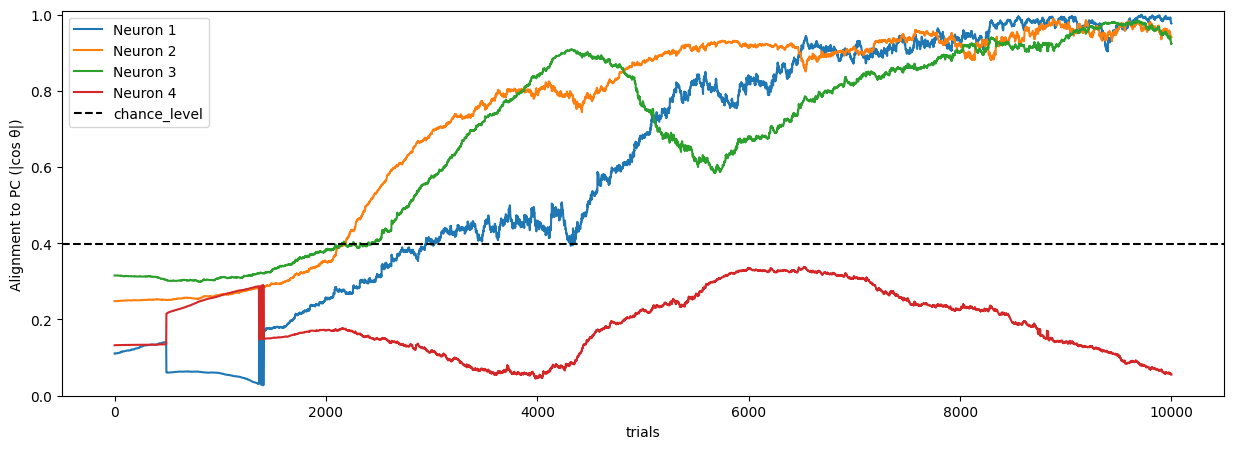

W after first phase: [[-1.32379380e-01 -9.45650833e-02  1.80306979e-01  1.00427082e-01
   1.51070081e-01  1.14680082e-02 -1.12850354e-01 -1.08470894e-01
   1.73674782e-01 -9.78229611e-02 -8.64084824e-02  4.69629986e-02
  -4.81938884e-02 -1.20441793e-01  2.64542530e-03  1.72594818e-01
  -5.31958199e-02  6.79880619e-02 -5.33912163e-02 -3.95867172e-02
   5.82856083e-04 -1.32780213e-01  1.65223250e-01  1.49642750e-01
  -2.21676543e-01 -5.63105918e-03  1.25143486e-01  5.22276277e-02
  -1.69157403e-01 -2.98974934e-02  1.93397540e-03 -1.12134682e-01
  -6.74963188e-02  1.01071411e-01 -1.55672786e-01 -1.00590089e-01
  -2.72712679e-02 -1.95108054e-03 -9.04665923e-02  1.40416731e-01
   4.67986316e-02  1.57845220e-01  1.17347383e-02 -1.64924502e-01
  -1.28297990e-02 -1.34900637e-01 -8.32102612e-02 -3.03151672e-02
  -1.29553861e-01 -4.07720183e-04  8.61553870e-02 -1.79186103e-02
   9.33760738e-02 -1.93796955e-01  4.56300329e-02  1.93736699e-02
   2.10833804e-01 -1.05269330e-01  2.76785620e-02 -5.55

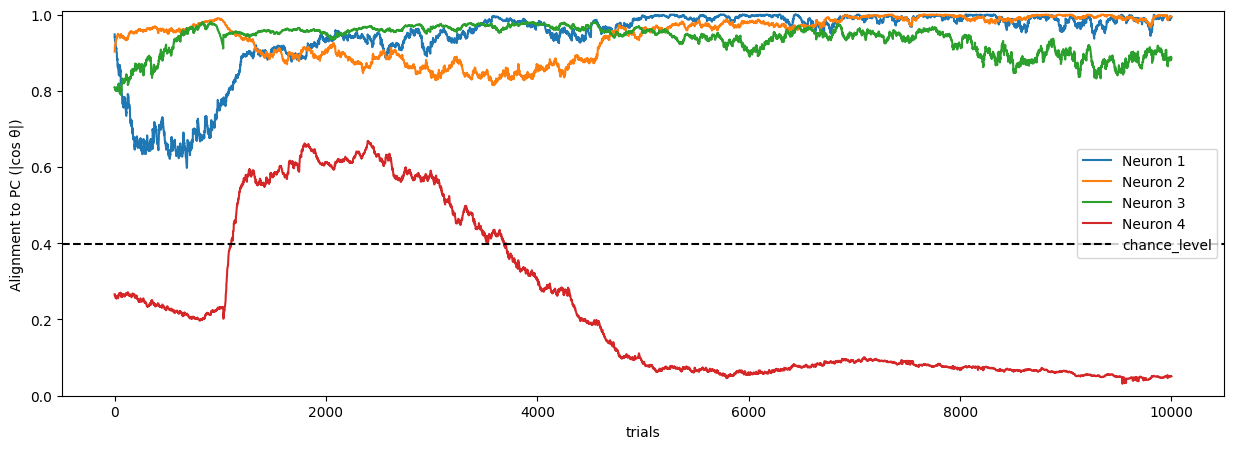

after second phase: model.W = [[-1.09225560e-01 -4.46465083e-02  2.09008372e-01  1.08005447e-01
   1.48097333e-01 -6.51795881e-02 -1.88921173e-01 -5.74363108e-02
   1.26336237e-01 -9.30841076e-02 -8.00345312e-02  8.72622796e-02
  -6.98959815e-02 -1.72796590e-01  8.94347829e-03  1.57774756e-01
  -2.16805131e-02  5.77321865e-02 -2.54901409e-03 -4.28537976e-02
  -1.21536960e-02 -1.56165296e-01  1.49638216e-01  1.58449076e-01
  -1.42313134e-01 -3.77721299e-02  8.47832412e-02 -3.66276120e-03
  -1.71071140e-01  1.76112632e-02  5.71602317e-03 -1.28633423e-01
  -4.08251748e-02  7.90864133e-02 -1.55319378e-01 -1.07187604e-01
  -9.56872222e-02  7.07236256e-03 -1.03253169e-01  7.60942027e-02
   6.79684981e-02  1.39331079e-01  3.63390597e-02 -1.88824431e-01
  -3.14792919e-02 -6.61247176e-02 -1.26020339e-01 -2.12410536e-02
  -5.63671132e-02  3.11240314e-02  7.66468354e-02 -3.35059255e-02
   6.49433261e-02 -2.58116860e-01  7.77577544e-02  4.76758749e-02
   1.95706260e-01 -8.36376546e-02 -3.63335688e

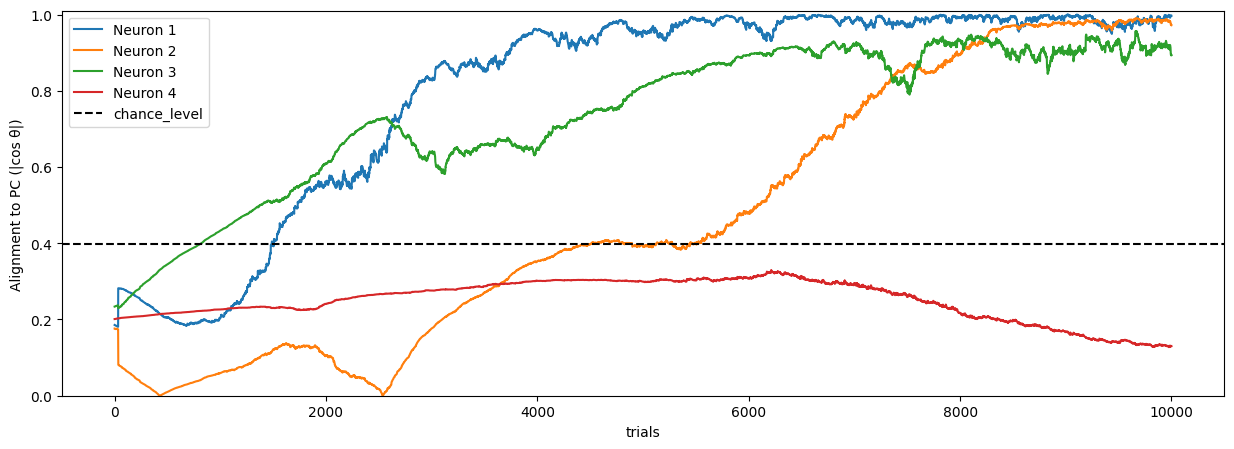

W after first phase: [[ 0.12270864  0.01219809 -0.14614393 -0.08259594 -0.1851365   0.07691666
   0.180829    0.06896547 -0.11423192  0.11693231  0.00698539 -0.0742537
   0.08544907  0.15050656  0.00170137 -0.1447232  -0.01292349 -0.02815358
  -0.02398765  0.08111358  0.06035509  0.08467185 -0.13264585 -0.16045502
   0.17529342 -0.00816248 -0.12118434  0.03259438  0.13898295 -0.02630662
   0.01277506  0.07749272  0.05126521 -0.10262154  0.18506794  0.05847086
   0.01623674 -0.01866487  0.1564822  -0.12649529 -0.04774139 -0.17057618
  -0.03931604  0.14078022 -0.01035055  0.05170707  0.04996539  0.01296335
   0.04837131 -0.0199176  -0.03456327  0.05558117 -0.04153912  0.19311664
  -0.06649837 -0.06343933 -0.15549548  0.06786972  0.00298779 -0.01707676
   0.04786882  0.01639045  0.05622111  0.0891394 ]
 [-0.02834867  0.06845591  0.023933    0.02534081  0.13369679 -0.23183679
  -0.25370374 -0.00382654 -0.00882294 -0.05743871  0.09395803  0.00227678
  -0.17391165 -0.13617972  0.03764721  0.

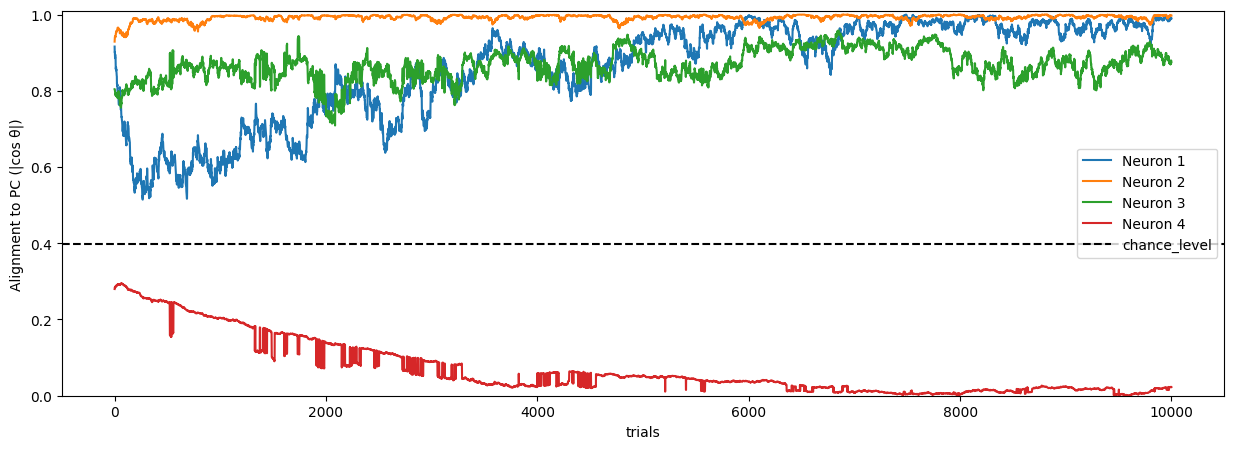

after second phase: model.W = [[ 1.03909252e-01  3.72635697e-02 -1.99400901e-01 -1.02975562e-01
  -1.45720150e-01  7.22379258e-02  1.90076271e-01  5.34541642e-02
  -1.16285910e-01  8.92078417e-02  7.02498526e-02 -8.57805226e-02
   7.31697871e-02  1.69166541e-01 -9.41765284e-03 -1.51585089e-01
   1.67462796e-02 -5.13540449e-02 -3.28895810e-03  4.31374397e-02
   1.82520374e-02  1.42988781e-01 -1.41564857e-01 -1.54933430e-01
   1.31977319e-01  3.47679540e-02 -8.37928026e-02  1.17417009e-02
   1.63493619e-01 -2.16235917e-02 -7.59815580e-03  1.20586219e-01
   3.69603320e-02 -7.56934598e-02  1.53318855e-01  1.01767387e-01
   9.21116865e-02 -9.99808126e-03  1.03775288e-01 -7.19550397e-02
  -6.57756611e-02 -1.38212562e-01 -3.82651046e-02  1.82734598e-01
   2.67663570e-02  5.52517568e-02  1.16525454e-01  2.31976722e-02
   4.83071158e-02 -3.12601264e-02 -6.81236767e-02  3.43090482e-02
  -5.92201759e-02  2.50508371e-01 -7.85645048e-02 -5.09423379e-02
  -1.84881053e-01  8.10966298e-02  3.90642102e

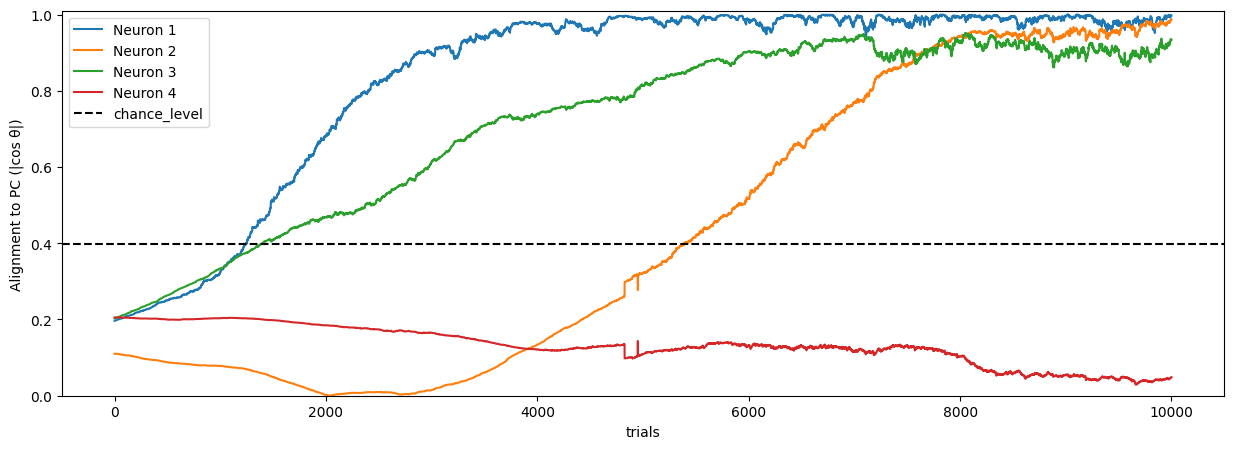

W after first phase: [[-8.33961482e-04 -7.71873522e-02 -2.63045613e-02 -3.41208364e-02
  -1.48464098e-01  2.07256168e-01  2.66919131e-01  1.89411391e-02
  -1.41064196e-02  7.39896814e-02 -7.80552211e-02  2.67785743e-02
   1.67947995e-01  1.46202500e-01 -4.49614961e-02 -1.34733262e-01
  -3.29876503e-02  5.08305980e-02 -6.70002165e-02  1.33923262e-01
   1.33401991e-01 -3.35920448e-02 -4.19017377e-02 -1.94486256e-01
   1.58108757e-02 -3.21585047e-02 -1.56048985e-01  1.01114920e-01
   1.12364708e-01 -4.08327920e-03 -9.69385037e-02 -3.52946632e-02
   1.43443453e-02 -8.15828361e-02  1.01322953e-01 -2.16548316e-02
  -3.77373548e-02 -3.50711261e-02  6.89625218e-02 -7.73646171e-02
  -4.80265673e-02 -1.92011591e-01 -5.69700646e-02  1.57361019e-01
  -1.35761580e-01 -4.83986196e-02 -1.64140662e-01  4.83574462e-02
  -5.76601625e-03  4.51055443e-02  8.62163498e-02 -1.43919060e-02
  -2.75640104e-02  1.14431380e-01 -9.94012166e-02 -9.89502620e-02
  -8.26400900e-02  1.45647874e-01  2.14885163e-02 -8.43

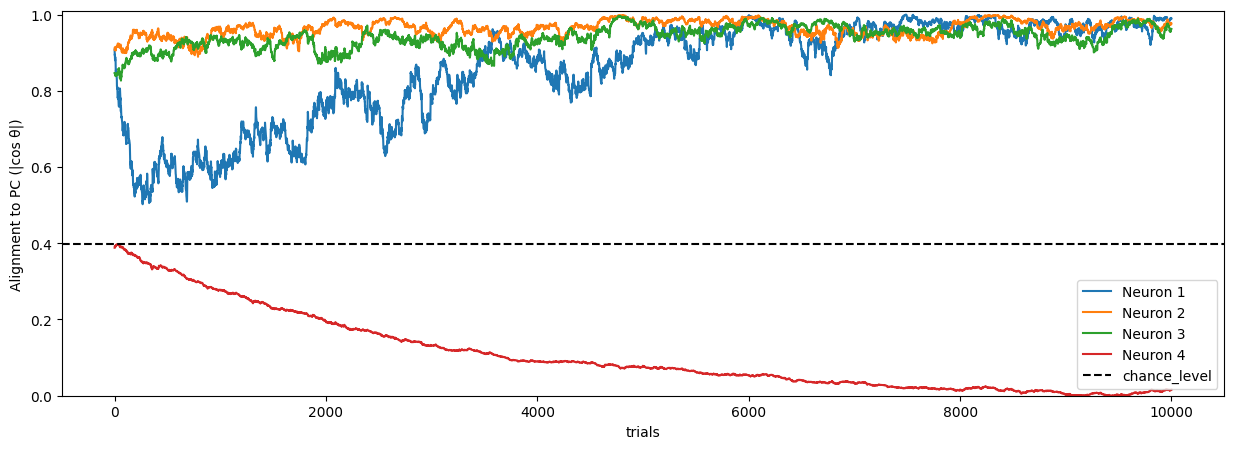

after second phase: model.W = [[ 0.00169611 -0.09389215 -0.11087591 -0.07345031 -0.09559966  0.2462122
   0.28937083 -0.04111467  0.03301809  0.06562096 -0.01318225 -0.05999343
   0.15505202  0.20906032 -0.04368742 -0.09744595 -0.04436363  0.02876951
  -0.09509507  0.110169    0.09993947  0.05893478 -0.05633599 -0.15232358
  -0.04141959  0.02152572 -0.0500028   0.14287369  0.12504104 -0.06545394
  -0.06736516  0.03565205 -0.03179897 -0.03232524  0.09040525  0.01643086
   0.12180014 -0.03328758  0.04779193  0.02961179 -0.05914961 -0.12798941
  -0.08470446  0.1815005  -0.05186758 -0.09071565  0.00492891  0.01223798
  -0.07855731 -0.02412552  0.05424344  0.00445557  0.02249354  0.20397594
  -0.12809117 -0.08780101 -0.09068969  0.08890265  0.09304966 -0.07750724
   0.06597327  0.02944626  0.05006271  0.24655064]
 [ 0.12429248  0.07583625 -0.20255617 -0.09931017 -0.14381818  0.0054517
   0.13287132  0.07832024 -0.15089735  0.08557321  0.08864551 -0.08247281
   0.03707071  0.13417894  0.0029

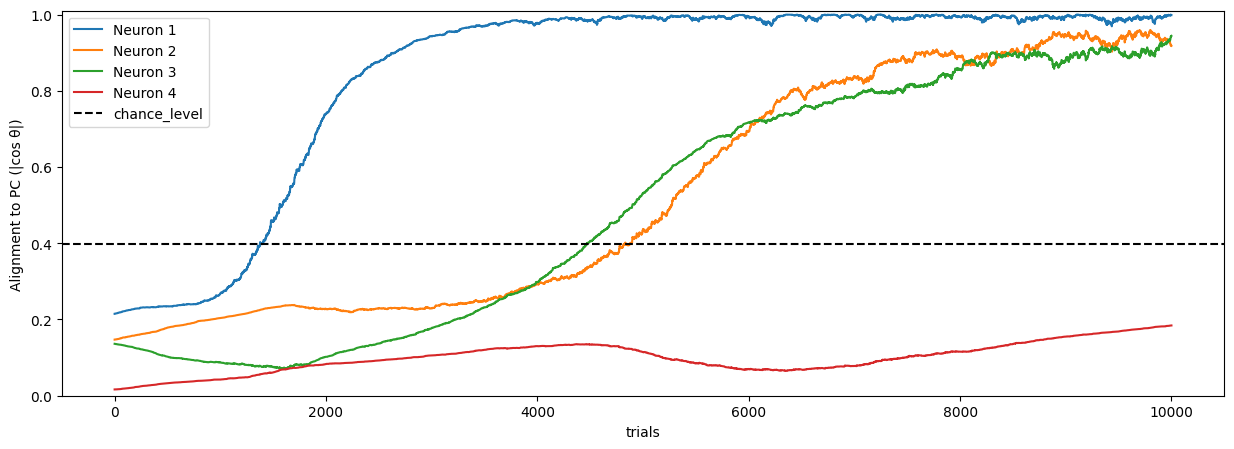

W after first phase: [[-0.17687081 -0.1235394   0.17482479  0.08077539  0.17563295  0.02110259
  -0.08487616 -0.10936766  0.16676956 -0.11340266 -0.07580084  0.04154051
  -0.01929454 -0.13904749  0.02149992  0.21808927 -0.08005283  0.09189426
  -0.06518065  0.01102086  0.01865448 -0.17975192  0.19746681  0.16563303
  -0.25383912 -0.0019061   0.16379949  0.08040425 -0.15706191 -0.04163896
   0.01721025 -0.16300155 -0.10808249  0.12961143 -0.20710482 -0.10514864
  -0.04536151 -0.03728239 -0.11352964  0.20763578  0.07923812  0.15058286
   0.06159409 -0.21235244 -0.03572501 -0.14804918 -0.08992187 -0.03320055
  -0.15179822 -0.00367745  0.07918948 -0.01853958  0.10321746 -0.22055867
   0.0935038   0.01772442  0.21723159 -0.13415169  0.0273256  -0.02405034
  -0.17844298  0.03221619 -0.05666339  0.0251509 ]
 [-0.0569701  -0.16541588  0.01766593 -0.00145736 -0.11408577  0.26556066
   0.32387566 -0.0090323   0.07800288  0.05509974 -0.12883626  0.03037079
   0.22679925  0.17420475 -0.01015244 -0

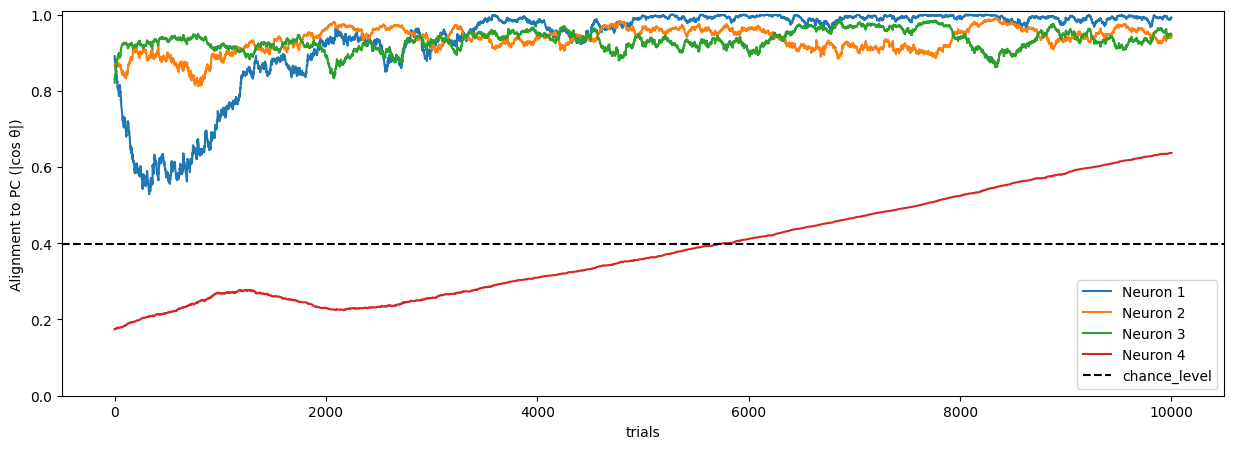

after second phase: model.W = [[-0.15310698 -0.10728617  0.23859419  0.11588178  0.16429396  0.02493313
  -0.12826601 -0.10195409  0.19440289 -0.1011555  -0.11848567  0.08995939
  -0.02582526 -0.14467294 -0.00704573  0.17910295 -0.05243742  0.09467562
  -0.04993407 -0.01062844  0.02970689 -0.19196143  0.184549    0.15348816
  -0.22250902 -0.04132545  0.09923671  0.06456369 -0.182753   -0.00915127
  -0.02111795 -0.16296521 -0.07448714  0.09819209 -0.17634645 -0.14069487
  -0.07330483 -0.00769796 -0.12127385  0.12594401  0.06913039  0.13732173
   0.01118134 -0.18175872 -0.06473833 -0.13820617 -0.16910653 -0.02486828
  -0.11986109  0.0294222   0.13179    -0.04295463  0.10320927 -0.26386298
   0.04974344  0.02480262  0.23454829 -0.08020327 -0.00327669 -0.05042214
  -0.24116147  0.00541792 -0.0629266  -0.0198717 ]
 [-0.07636809 -0.17707667 -0.03965507 -0.04800383 -0.04152745  0.34185097
   0.32857422 -0.10858441  0.13392693  0.04456855 -0.05876228 -0.03087266
   0.19379467  0.22128595 -0.06

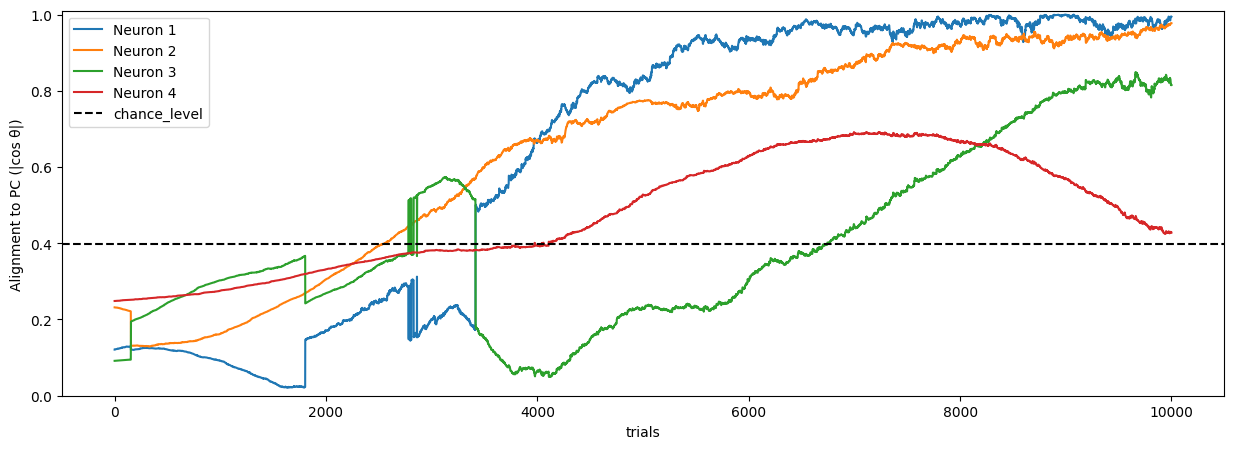

W after first phase: [[-0.00287648  0.11392184  0.03017064  0.05400067  0.15959941 -0.23987838
  -0.28888194 -0.02972327  0.00593318 -0.11674926  0.07791348 -0.05077724
  -0.19794912 -0.19318516  0.06733156  0.15127476  0.03556204 -0.07226871
   0.06909481 -0.21496228 -0.14632753  0.02257061  0.05296167  0.20858185
  -0.03790572  0.0340297   0.1614823  -0.13178963 -0.14100843  0.01717436
   0.1118564   0.02866501  0.01041726  0.07005645 -0.13041596  0.04988932
   0.01626902  0.03371011 -0.06365982  0.10238714  0.04909931  0.20914028
   0.08057101 -0.19014422  0.16905126  0.07193884  0.17911287 -0.06534132
   0.00583793 -0.04285501 -0.08883741  0.04546518 -0.00316054 -0.10257004
   0.1226028   0.09517479  0.09408356 -0.1823476   0.03761734  0.08309147
   0.19750002  0.07619027  0.01719305 -0.18776394]
 [ 0.12851259  0.08579856  0.08693756  0.08333159 -0.14343371 -0.14953245
  -0.13242652  0.16467943 -0.06750415 -0.04654816 -0.17643553 -0.02216723
  -0.02183447 -0.1961152   0.06558598  0

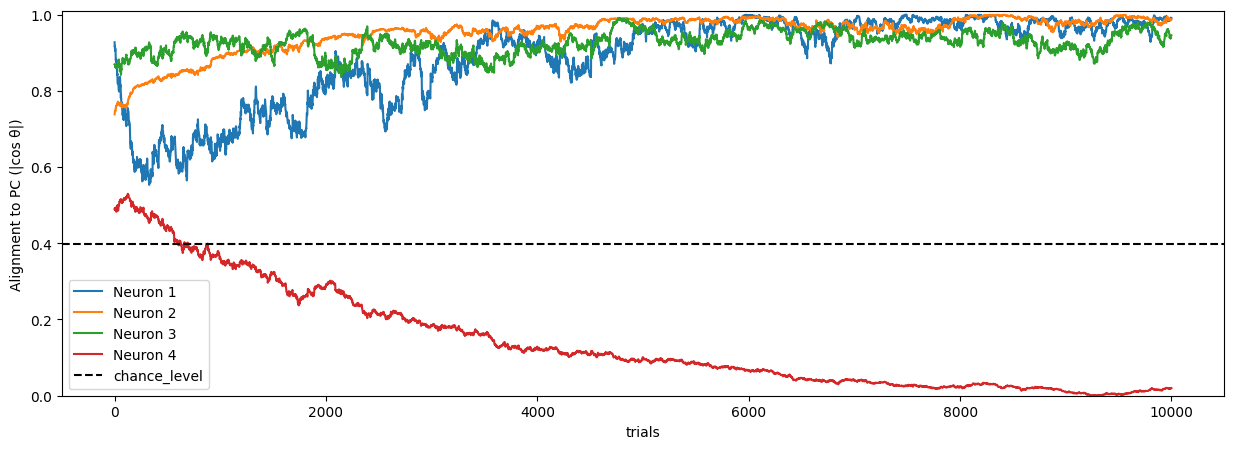

after second phase: model.W = [[ 7.60874590e-03  1.02285674e-01  1.01254345e-01  6.97661043e-02
   8.75468412e-02 -2.53973643e-01 -2.89817275e-01  4.86472682e-02
  -4.42038693e-02 -6.25314704e-02  1.75517351e-02  5.54601680e-02
  -1.57258056e-01 -2.08015416e-01  4.58384917e-02  9.06782064e-02
   4.75410923e-02 -3.39060835e-02  9.94927799e-02 -1.14046862e-01
  -1.02713692e-01 -5.36834110e-02  4.83137744e-02  1.48247247e-01
   5.49582882e-02 -2.07888153e-02  4.46404493e-02 -1.48909627e-01
  -1.19776126e-01  6.62782679e-02  7.08960904e-02 -2.85235498e-02
   3.67184114e-02  2.77460564e-02 -8.09021577e-02 -8.47554085e-03
  -1.22553962e-01  3.32278209e-02 -3.94203150e-02 -3.81678508e-02
   5.74722527e-02  1.22556571e-01  8.60475383e-02 -1.77744617e-01
   5.68510709e-02  9.91179797e-02  3.49524345e-03 -9.57869716e-03
   8.65150616e-02  2.24035920e-02 -6.21793912e-02 -4.41406718e-04
  -2.84452805e-02 -1.94857928e-01  1.28796612e-01  8.72710323e-02
   8.18133568e-02 -8.78262256e-02 -9.43748259e

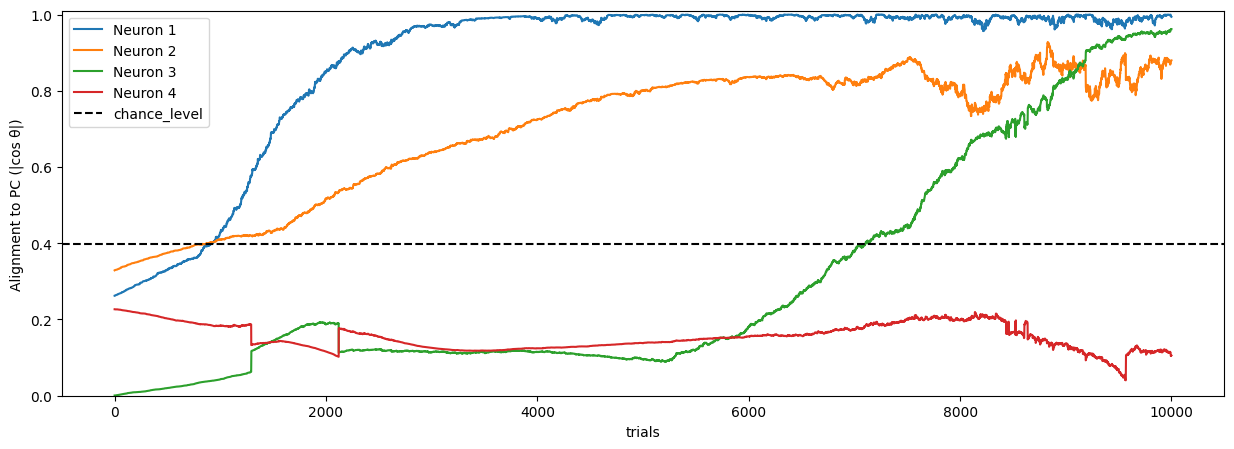

W after first phase: [[-9.52528173e-02  7.51472621e-03  1.35387466e-01  8.07368963e-02
   2.04836563e-01 -1.57265400e-01 -2.82298578e-01 -7.65839504e-02
   1.00416205e-01 -1.08651182e-01  7.78969105e-04  3.60900262e-02
  -1.67606175e-01 -1.91024029e-01  2.54557960e-02  2.07946706e-01
   1.86635977e-02  2.43237968e-03  2.50943573e-02 -1.12975233e-01
  -1.17403833e-01 -3.43065981e-02  1.22372762e-01  2.28861299e-01
  -1.50238726e-01  2.51839778e-02  1.66704800e-01 -7.47856279e-02
  -1.84223034e-01  2.87892304e-02  7.65437317e-02 -4.56550209e-02
  -4.37283119e-02  1.12067678e-01 -2.11896173e-01 -5.26352076e-02
  -4.20644690e-03  3.22709348e-02 -1.45432635e-01  1.44980593e-01
   7.97997786e-02  2.50976282e-01  5.82408019e-02 -2.13399835e-01
   8.78167521e-02 -8.90465351e-03  3.68850548e-02 -8.11075528e-02
  -4.38606268e-02 -3.08801558e-03 -2.08433341e-02 -2.04425913e-02
   4.42183148e-02 -2.25836490e-01  1.23919471e-01  1.01230534e-01
   1.95936772e-01 -1.64377751e-01 -2.15362481e-03  3.94

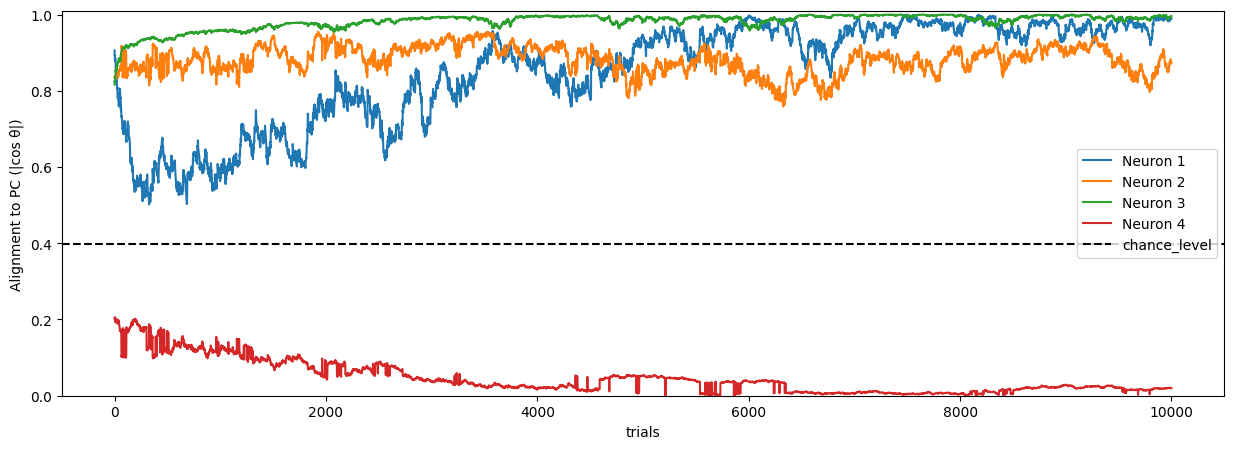

after second phase: model.W = [[-5.02382643e-02  3.99469318e-02  1.62195688e-01  9.35800917e-02
   1.27496361e-01 -1.85080114e-01 -2.67165079e-01 -1.81950536e-05
   3.44628556e-02 -8.21387112e-02 -2.48061040e-02  7.77003107e-02
  -1.29609402e-01 -2.07843668e-01  3.11162354e-02  1.31095797e-01
   1.94597731e-02  6.52205573e-03  6.00150375e-02 -8.74576509e-02
  -7.00555290e-02 -1.03126741e-01  1.01231958e-01  1.66299729e-01
  -3.67635789e-02 -2.95749141e-02  7.01173261e-02 -9.34614602e-02
  -1.53549589e-01  5.07653140e-02  4.47298651e-02 -7.87940087e-02
   2.16978660e-03  5.53899832e-02 -1.28157327e-01 -5.83567269e-02
  -1.18261382e-01  2.53867831e-02 -7.87842426e-02  1.56800182e-02
   6.72238594e-02  1.43758548e-01  7.01069235e-02 -1.97296980e-01
   1.88893740e-02  2.99667774e-02 -5.83452523e-02 -1.87203963e-02
   2.56933077e-02  2.98719746e-02 -1.13453920e-03 -1.92679880e-02
   1.39822276e-02 -2.43526145e-01  1.15675068e-01  7.81269827e-02
   1.42547902e-01 -9.24448168e-02 -7.58309702e

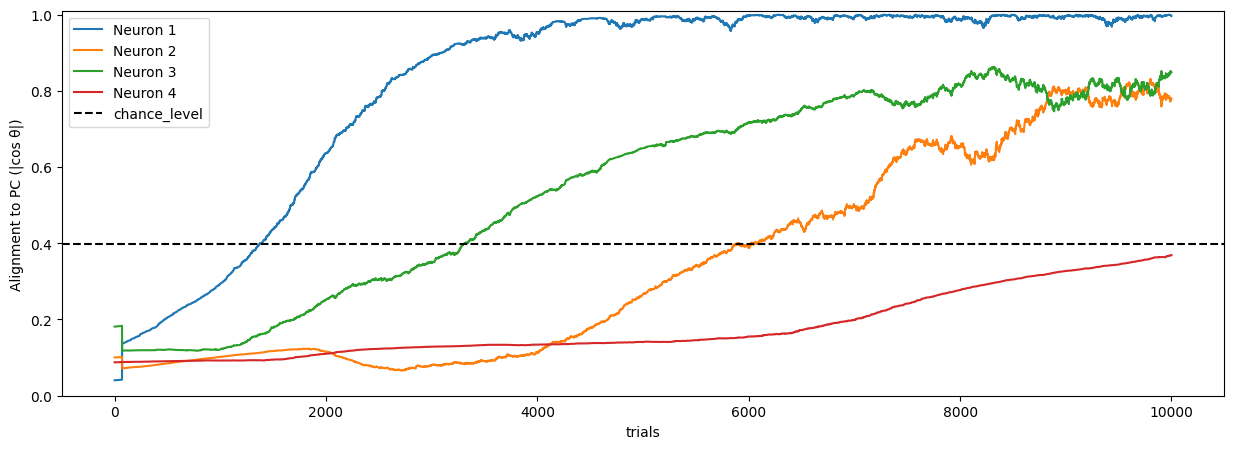

W after first phase: [[ 0.13501941  0.09589804  0.07938408  0.08080638 -0.14420472 -0.164038
  -0.14180873  0.17005899 -0.07839414 -0.04473762 -0.16781736 -0.02407531
  -0.03011494 -0.19903298  0.0681015   0.00224588 -0.0151319   0.03004108
   0.02970869 -0.14049222  0.0658255  -0.3038188   0.01671714  0.04066943
   0.1748712  -0.11136846 -0.15918979 -0.02798573 -0.11943201 -0.0342481
   0.06625061 -0.06783832  0.06266262 -0.04186911  0.20106658  0.05564387
  -0.24650679 -0.07363251  0.24257331 -0.20803551  0.05370974 -0.10943697
   0.03084292 -0.15634857 -0.00843854  0.00349565 -0.09778526  0.15649165
   0.08613281 -0.01568106  0.00366251  0.12691007 -0.03410893 -0.09565108
   0.06557395 -0.06483303  0.084822   -0.045633   -0.05415087  0.0049753
  -0.41760442  0.00166622 -0.02298845 -0.20213096]
 [-0.05421516  0.22973103 -0.08670042  0.2055205  -0.00160377  0.17938815
   0.06062314  0.09103161  0.11920593 -0.10638705  0.02142587 -0.00323388
  -0.03513154 -0.12786237  0.19888306  0.120

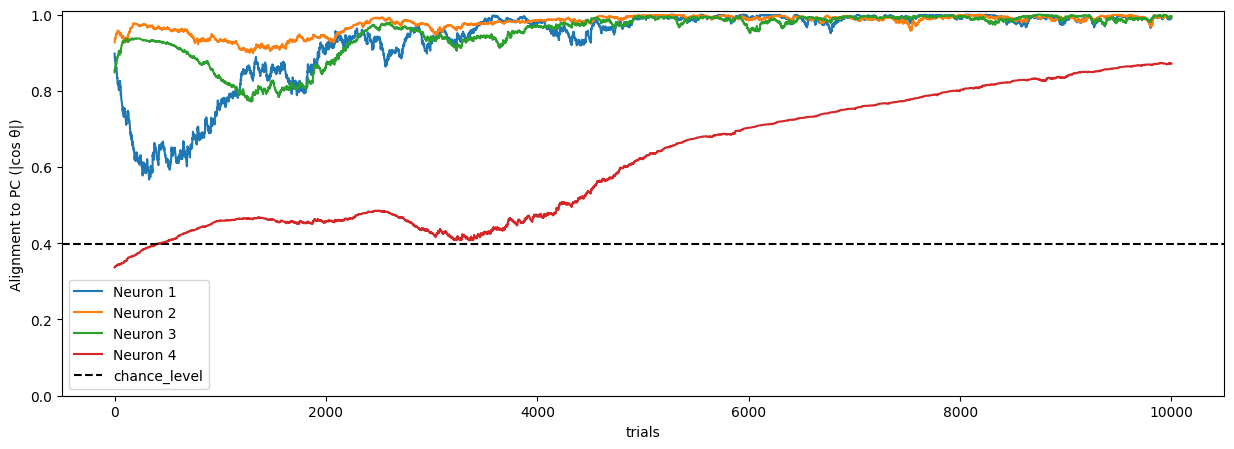

after second phase: model.W = [[ 0.13504456  0.03345189  0.04154097  0.05076297 -0.21062421 -0.0140712
   0.02673169  0.15761738 -0.05447646 -0.00849775 -0.19987055 -0.0421136
   0.07352964 -0.08836627  0.04178261 -0.0586761  -0.04710733  0.06075681
  -0.02888394 -0.06701104  0.14311719 -0.30816676 -0.0068392  -0.05441432
   0.15649901 -0.11669061 -0.21091548  0.06216836 -0.05417388 -0.06969867
   0.01639628 -0.07026499  0.04658254 -0.06670868  0.26412245  0.05160377
  -0.20867816 -0.09787563  0.27866804 -0.21232743  0.02158389 -0.20233573
  -0.01855322 -0.05867569 -0.06609959 -0.05705785 -0.13897185  0.1790725
   0.04586499 -0.01916983  0.05568848  0.12903203 -0.01891992 -0.0016819
  -0.00986453 -0.12339988  0.04080379  0.01985139 -0.01341946 -0.04486876
  -0.4509395   0.00452376 -0.00732614 -0.06565225]
 [ 0.01735182  0.13331463 -0.10208206  0.0913012  -0.00484272  0.03985659
  -0.00893766  0.01842683  0.08320638 -0.09675413 -0.03057457 -0.14346887
  -0.0746485  -0.11573904  0.129345

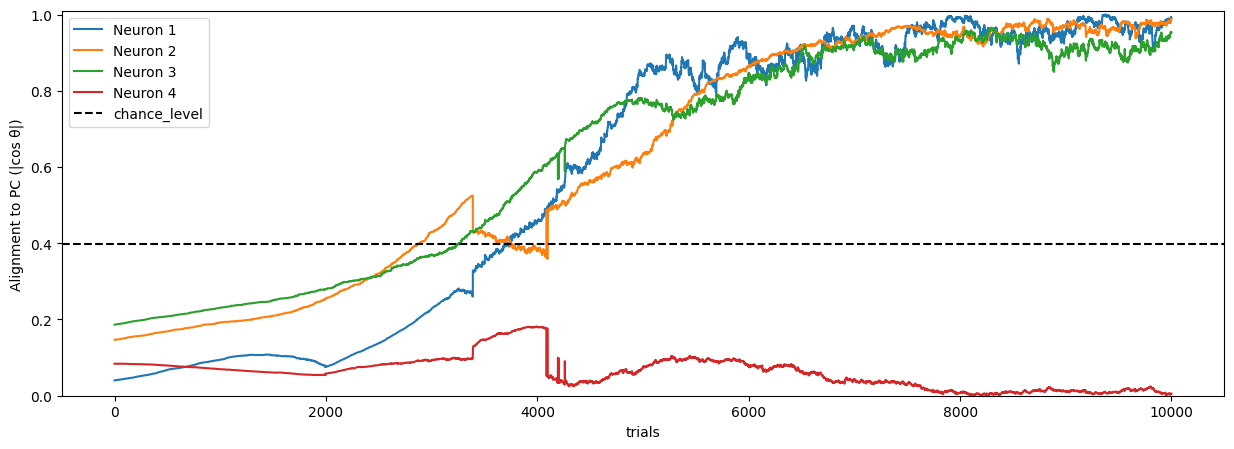

W after first phase: [[ 5.36727519e-02 -7.18818272e-02 -5.49704750e-02 -4.37594295e-02
  -1.60295098e-01  1.78765965e-01  2.49618668e-01  5.03210325e-02
  -1.68757433e-02  6.81862845e-02 -6.82794471e-02  2.93764860e-03
   1.67631249e-01  1.51629117e-01 -4.37364795e-02 -1.50795479e-01
  -3.23366907e-02  4.18866680e-02 -7.04254035e-02  1.08069114e-01
   1.33131823e-01 -4.06575882e-02 -5.70529749e-02 -1.78114179e-01
   5.47766186e-02 -3.52621851e-02 -1.45959240e-01  1.01285155e-01
   1.28020564e-01 -4.13675698e-02 -7.88219829e-02 -1.51782613e-02
   2.36797839e-02 -7.59812749e-02  1.72890363e-01  8.35879381e-03
  -1.01157642e-02 -4.62547330e-02  1.22264900e-01 -1.09675270e-01
  -4.41506679e-02 -2.02453916e-01 -5.74582267e-02  1.53383155e-01
  -1.09208221e-01 -5.49443343e-02 -9.60129276e-02  7.23234678e-02
   3.89558452e-03  1.25583125e-02  7.78998152e-02  1.76083976e-02
   1.85654203e-03  1.33792366e-01 -9.17250983e-02 -1.03253399e-01
  -1.12413833e-01  1.39200029e-01  2.04398761e-02 -5.46

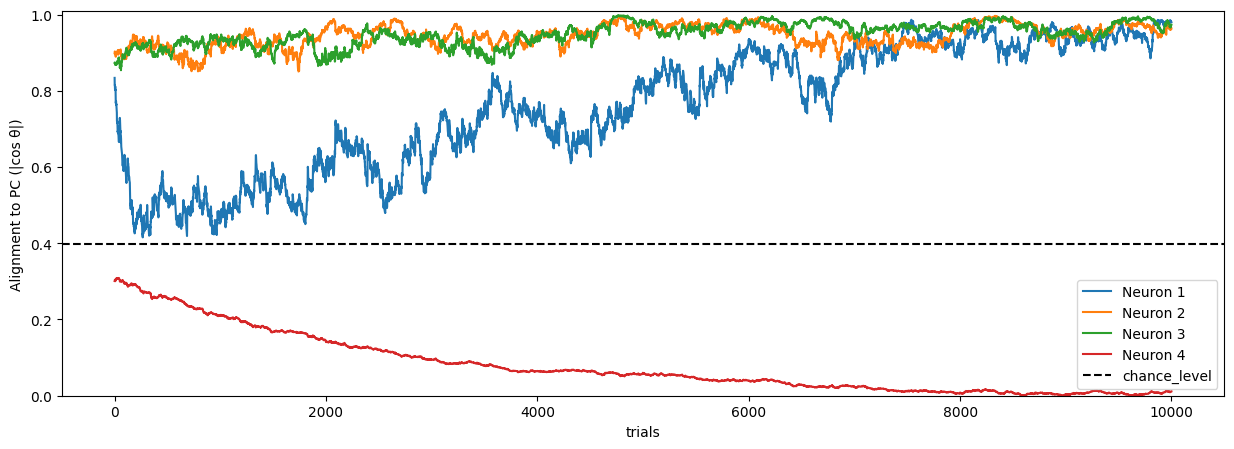

after second phase: model.W = [[ 1.38232350e-02 -8.48781316e-02 -1.18401297e-01 -7.53790855e-02
  -1.07850595e-01  2.37453267e-01  2.88221129e-01 -2.99328370e-02
   2.11120617e-02  6.80824281e-02 -1.38897066e-02 -6.49726691e-02
   1.54116906e-01  2.07016264e-01 -4.05057696e-02 -1.04801032e-01
  -4.23420154e-02  2.53552583e-02 -9.12545794e-02  1.04534333e-01
   1.00391906e-01  5.60455769e-02 -6.37881260e-02 -1.56705187e-01
  -2.46066590e-02  1.92537720e-02 -5.98882785e-02  1.38161755e-01
   1.28143647e-01 -6.62156209e-02 -6.33299610e-02  4.04981529e-02
  -2.59708126e-02 -3.80144349e-02  1.05554528e-01  2.50410756e-02
   1.15565483e-01 -3.55993264e-02  6.23031455e-02  1.61602028e-02
  -5.98936684e-02 -1.37444877e-01 -8.35665700e-02  1.82774137e-01
  -4.85886647e-02 -8.39208914e-02  9.53522472e-03  1.91406044e-02
  -6.96182557e-02 -2.61879137e-02  4.79132862e-02  1.13321485e-02
   1.65396153e-02  2.11484834e-01 -1.27102007e-01 -9.08835776e-02
  -9.76420057e-02  9.00342254e-02  9.08756195e

<Figure size 640x480 with 0 Axes>

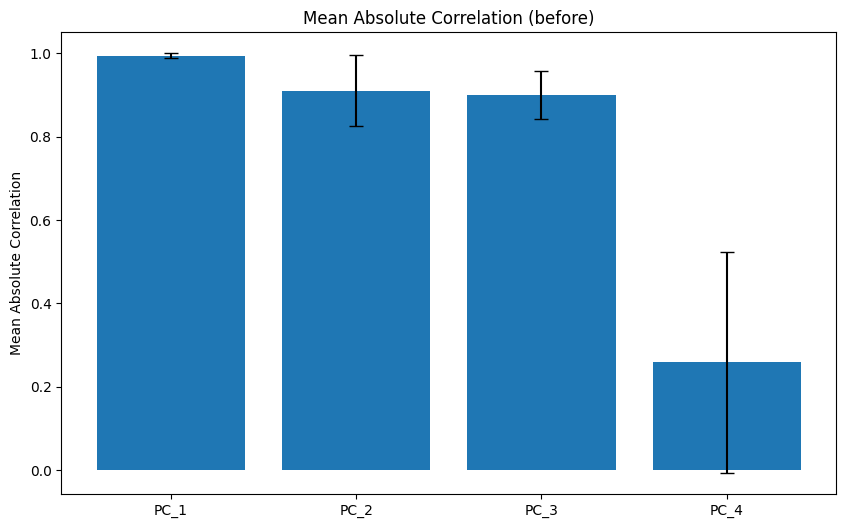

<Figure size 640x480 with 0 Axes>

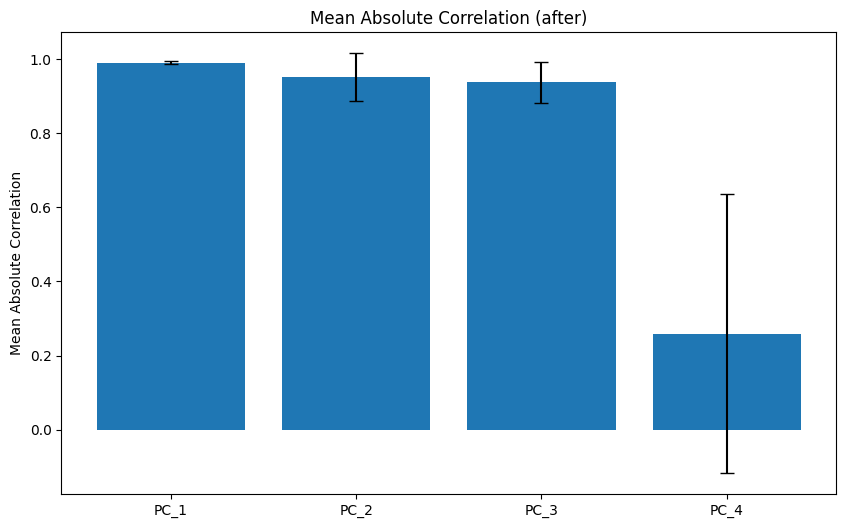

In [30]:
leen_model  = OneShotLeenCompletePCA(**model_paras)

# leen_model = OneShotLeenReislebenPCA(**model_paras)

two_phase_training_testing(leen_model, X_before, X_after, m, model_paras_after = model_paras_after, runs = 10, graph = True)

In [8]:
from hebbian.utils import pca_topk
from scipy.stats import pearsonr
from hebbian.utils import best_match_align_timeseries



def random_projection_chance_corr1(X, n_samples=1000, seed=None):
    """
    Calculate the expected absolute correlation between a random projection 
    of X and the PC projections of X.
    
    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input data
    n_samples : int, default=1000
        Number of random vectors to sample for Monte Carlo estimation
    seed : int or None
        Random seed
        
    Returns
    -------
    expected_corr : float
        Expected absolute correlation between random projection and PC projections
    std_corr : float
        Standard deviation of correlations (for reference)
    """
    X = np.asarray(X, dtype=float)
    n, d = X.shape
    
    # Center the data
    Xc = X - X.mean(axis=0, keepdims=True)
    
    # Get PCs
    _, _, PC_scores = pca_topk(X, d, center=True)
    print(f"shape of PC_scores: {PC_scores.shape}")
    
    # Sample random unit vectors
    rng = np.random.default_rng(seed)
    correlations = []
    
    for _ in range(n_samples):
        # Random unit vector in d-dimensional space
        w = rng.normal(size=d)
        w = w / (np.linalg.norm(w) + 1e-12)
        
        # Project X onto random direction
        y_random = Xc @ w
        
        # Compute correlation with each PC
        pc_corrs = []
        # print(f"shape of y_random: {y_random.shape}")
        
        # for j in range(min(d, PC_scores.shape[1])):
        # for j in range(2):
        # calculate the covariance between y_random and PC_scores[:, 0]
        cov = np.cov(y_random, PC_scores[:, 0])/np.cov(PC_scores[:, 0], PC_scores[:, 0])
        # pc_corrs.append(abs(r))
        pc_corrs.append(abs(cov[0, 1]))

        
        # Take max correlation (best match, like Hungarian algorithm does)
        correlations.append(max(pc_corrs))
    
    return np.mean(correlations), np.std(correlations)


def random_projection_chance_corr(X, m=2, n_samples=1000, metric="corr", absolute=True, seed=None):
    """
    Calculate the expected absolute correlation between random projections 
    of X and the PC projections of X, using the same matching procedure
    as the actual analysis (best_match_align_timeseries).
    
    This generates m random unit vectors, projects X onto them, and uses
    Hungarian matching to find optimal alignment with PCs, just like the
    real analysis does.
    
    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input data
    m : int, default=2
        Number of random projections (should match output_dim of your model)
    n_samples : int, default=1000
        Number of random vector sets to sample for Monte Carlo estimation
    metric : {"corr", "cosine"}, default="corr"
        Metric to use (should match what you use in best_match_align_timeseries)
    absolute : bool, default=True
        Whether to use absolute correlations (should match your usage)
    seed : int or None
        Random seed
        
    Returns
    -------
    expected_corr : float
        Expected absolute correlation after optimal matching
    std_corr : float
        Standard deviation of correlations (for reference)
    all_corrs : ndarray, shape (n_samples, m)
        All correlation values from each trial (for distribution analysis)
    """
    X = np.asarray(X, dtype=float)
    n, d = X.shape
    
    # Center the data
    Xc = X - X.mean(axis=0, keepdims=True)
    
    # Get PC scores (top m PCs)
    _, _, PC_scores = pca_topk(X, d, center=True)
    PC_scores_m = PC_scores[:, :m]  # Use only top m PCs
    
    # Sample random projections
    rng = np.random.default_rng(seed)
    all_similarities = []
    
    for trial in range(n_samples):
        # Generate m random unit vectors in d-dimensional space
        W_random = rng.normal(size=(m, d))
        # Normalize each row to unit length
        W_random = W_random / (np.linalg.norm(W_random, axis=1, keepdims=True) + 1e-12)
        
        # Project X onto random directions: Y_random = Xc @ W_random.T
        # Shape: (n, d) @ (d, m) = (n, m)
        Y_random = Xc @ W_random.T
        
        # Use the same matching procedure as actual analysis
        perm, similarity, _, _ = best_match_align_timeseries(
            Y_random, PC_scores_m, 
            metric=metric, 
            absolute=absolute
        )
        
        # similarity is already the matched correlations
        all_similarities.append(similarity)
    
    all_similarities = np.array(all_similarities)  # Shape: (n_samples, m)
    
    # Compute statistics
    expected_corr = np.mean(all_similarities)
    std_corr = np.std(all_similarities)
    
    return expected_corr, std_corr, all_similarities


def random_projection_chance_corr_per_pc(X, m=2, n_samples=1000, metric="corr", absolute=True, seed=None):
    """
    Same as random_projection_chance_corr but returns per-PC statistics.
    
    Returns
    -------
    expected_corr_per_pc : ndarray, shape (m,)
        Expected correlation for each PC (after sorting by PC order)
    std_corr_per_pc : ndarray, shape (m,)
        Standard deviation for each PC
    """
    expected_corr, std_corr, all_similarities = random_projection_chance_corr(
        X, m, n_samples, metric, absolute, seed
    )
    
    # Sort similarities by PC order (they're already matched, but we want PC1, PC2, ...)
    # The similarities are already optimally matched, so we sort them
    all_similarities_sorted = np.sort(all_similarities, axis=1)  # Sort each row
    
    expected_corr_per_pc = np.mean(all_similarities_sorted, axis=0)
    std_corr_per_pc = np.std(all_similarities_sorted, axis=0)
    
    return expected_corr_per_pc, std_corr_per_pc, all_similarities_sorted



def analytical_chance_corr(input_dim):
    """
    Analytical approximation for expected correlation between random projection
    and PC projection, assuming isotropic data (all eigenvalues equal).
    
    This is a simplified case. For non-isotropic data, use random_projection_chance_corr.
    
    Parameters
    ----------
    input_dim : int
        Input dimensionality
        
    Returns
    -------
    float 
        Expected absolute correlation (approximate)
    """
    # For isotropic case, this reduces to the random vector chance level
    # For non-isotropic, it's more complex and depends on eigenvalue distribution
    return np.sqrt(2 / (np.pi * input_dim))

In [9]:
print(f"Analytical chance correlation: {analytical_chance_corr(N):.3f}")

Analytical chance correlation: 0.199


In [10]:
from hebbian.utils import generate_covariance_matrix
for i in range(2, 10, 1):
    N = i
    m = 2
    phi_deg = 45.0
    n_samples = 10001
    # get /sigma
    Sigma = np.array([[1.0, 0.2], [0.2, 1.0]])
    Sigma_rot = rotate_cov_nd(Sigma, np.deg2rad(phi_deg), axis1=0, axis2=1)

    X_before, X_after = instantiate_before_after_X(Sigma, Sigma_rot, N = N, seed=X_seed, n_samples=n_samples)
    print(f" input dimension = {N}")
    print(f"shape of X_before: {X_before.shape}")
    # In Y_aligned_training_testing_online or similar:
    expected_corr, std_corr = random_projection_chance_corr1(X_before, n_samples=1000)
    print(f"Expected chance correlation: {expected_corr:.3f} ± {std_corr:.3f}")

 input dimension = 2
shape of X_before: (10001, 2)
shape of PC_scores: (10001, 2)
Expected chance correlation: 0.639 ± 0.303
 input dimension = 3
shape of X_before: (10001, 3)
shape of PC_scores: (10001, 3)
Expected chance correlation: 0.498 ± 0.288
 input dimension = 4
shape of X_before: (10001, 4)
shape of PC_scores: (10001, 4)
Expected chance correlation: 0.419 ± 0.264
 input dimension = 5
shape of X_before: (10001, 5)
shape of PC_scores: (10001, 5)
Expected chance correlation: 0.385 ± 0.248
 input dimension = 6
shape of X_before: (10001, 6)
shape of PC_scores: (10001, 6)
Expected chance correlation: 0.350 ± 0.228
 input dimension = 7
shape of X_before: (10001, 7)
shape of PC_scores: (10001, 7)
Expected chance correlation: 0.315 ± 0.214
 input dimension = 8
shape of X_before: (10001, 8)
shape of PC_scores: (10001, 8)
Expected chance correlation: 0.306 ± 0.209
 input dimension = 9
shape of X_before: (10001, 9)
shape of PC_scores: (10001, 9)
Expected chance correlation: 0.285 ± 0.192


In [11]:
# In your notebook or analysis:

# Or get per-PC statistics
expected_per_pc, std_per_pc, _ = random_projection_chance_corr_per_pc(
    X_before, m=2, n_samples=1000
)
print(f"Expected chance correlation per PC: PC1={expected_per_pc[0]:.3f}, PC2={expected_per_pc[1]:.3f}")

Expected chance correlation per PC: PC1=0.664, PC2=0.951
